# Case Study 1 — Building a Mean-Variance Portfolio Pipeline

**STAT 4170 – Financial Time Series and Forecasting**

---

This notebook builds a sector-rotation portfolio pipeline using mean-variance theory and then checks how much I should actually trust it. The notebook is organized in six sections:

- **Section 1** — a cached data pipeline
- **Section 2** — how well we can even estimate $\boldsymbol{\mu}$ and $\boldsymbol{\Sigma}$
- **Section 3** — how sensitive the optimal weights are to those inputs
- **Section 4** — rebalancing and trading costs
- **Section 5** — a walk-forward backtest with a tearsheet
- **Section 6** — bonus comparisons

**Universe:** the eleven SPDR sector ETFs (XLC, XLY, XLP, XLE, XLF, XLV, XLI, XLB, XLRE, XLK, XLU) plus SPY as the market factor.

### Conventions I use everywhere

| Choice | What I picked | Why |
|---|---|---|
| Return type | simple daily returns (`pct_change()`) | a portfolio return is the weighted average of simple asset returns; log returns don't add up across assets |
| Annualization | mean $\times$ 252, vol $\times \sqrt{252}$, Sharpe $\times \sqrt{252}$ | standard i.i.d. scaling |
| Risk-free rate | 0 (noted wherever a Sharpe shows up) | keeps things simple; a T-bill series wouldn't change the ranking |
| Optimizer | budget-constrained MPT from Module 2: $\mathbf{w}^* = \tfrac{1}{\gamma}\hat{\boldsymbol{\Sigma}}^{-1}(\hat{\boldsymbol{\mu}}-\lambda\mathbf{1})$, with $\lambda$ chosen so $\mathbf{1}^\top\mathbf{w}=1$ | shorting and leverage allowed; the constrained versions use a solver in 3.5 |
| Base risk aversion | $\gamma = 3$ | middle of the $[0.1, 20]$ grid I test in 3.1 |
| Train / test split | first 60% train, last 40% test (Sections 3–4) | test data never feeds a weight |


In [1]:
# ============================================================================
# Setup: imports, plotting defaults, global configuration
# ============================================================================
from __future__ import annotations

import os, json, hashlib, datetime as dt
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import yfinance as yf     # Section 1 data pipeline
import cvxpy as cp        # Sections 3.5, 5, 6 constrained optimisation

mpl.rcParams.update({
    "figure.figsize": (10, 5.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ---- global configuration ---------------------------------------------------
SECTOR_ETFS = ["XLC", "XLY", "XLP", "XLE", "XLF", "XLV",
               "XLI", "XLB", "XLRE", "XLK", "XLU"]
MARKET      = "SPY"
TICKERS     = SECTOR_ETFS + [MARKET]

SECTOR_NAMES = {
    "XLC": "Comm. Services", "XLY": "Cons. Discretionary", "XLP": "Cons. Staples",
    "XLE": "Energy", "XLF": "Financials", "XLV": "Health Care",
    "XLI": "Industrials", "XLB": "Materials", "XLRE": "Real Estate",
    "XLK": "Technology", "XLU": "Utilities", "SPY": "S&P 500",
}

RETURN_KIND   = "simple"     # simple (arithmetic) returns everywhere
TRADING_DAYS  = 252
DATA_START    = "2010-01-01" # dropna() trims to the common window (XLC lists 2018-06)
CACHE_DIR     = "data_cache"
GAMMA_BASE    = 3.0          # base risk-aversion; grid-studied in Section 3.1
TRAIN_FRAC    = 0.60
RF_ANNUAL     = 0.0          # risk-free rate assumption (Sharpe uses 0)

SEED = 4170
rng = np.random.default_rng(SEED)

def annualize_return(mean_daily):   return mean_daily * TRADING_DAYS
def annualize_vol(std_daily):       return std_daily * np.sqrt(TRADING_DAYS)
def sharpe(returns, rf_annual=RF_ANNUAL):
    r = np.asarray(returns, float)
    excess = r.mean() - rf_annual / TRADING_DAYS
    sd = r.std(ddof=1)
    return np.nan if sd == 0 else excess / sd * np.sqrt(TRADING_DAYS)

def max_drawdown(returns):
    "Max drawdown of a simple-return series (as a positive fraction)."
    wealth = (1 + pd.Series(np.asarray(returns, float))).cumprod()
    peak = wealth.cummax()
    return float((1 - wealth / peak).max())

print("setup ok — universe:", TICKERS)

setup ok — universe: ['XLC', 'XLY', 'XLP', 'XLE', 'XLF', 'XLV', 'XLI', 'XLB', 'XLRE', 'XLK', 'XLU', 'SPY']


---
# Section 1 — Data Pipeline

The point of this section is a download function that caches to disk, so anyone can re-run the notebook without re-downloading everything each time.

**What the code below does**

1. `get_price_data()` — pulls daily adjusted closes for the 12 tickers with `yfinance` and saves them to a CSV. It only hits the internet if the saved file doesn't already cover the most recent finished trading day.
2. `get_returns()` — turns those prices into a clean `DataFrame` of daily simple returns, dates as the index, tickers as columns, any row with a NaN dropped.

### How the cache decides it's stale

The cache filename is a hash of the (sorted) ticker list plus the start date, so if I change the universe or the start date it makes a new file instead of quietly reusing the wrong one. On each call:

- No cache file yet → download everything and save it.
- Cache file exists → make one tiny request (`SPY`, last 10 days) to find the most recent *completed* trading day. I take the latest date strictly before today (US/Eastern) so a half-finished bar for the current session doesn't count. Then:
    - cache's last date $\ge$ that day → use the cache (the little SPY request is the only network call).
    - cache's last date $<$ that day → re-download the full history and overwrite.
- If that check throws (no internet) → just use whatever is cached and print a warning, so the notebook still runs offline once it's been cached once.

It also writes a small `.meta.json` next to the CSV with the ticker list, start date, download time, and last date. The CSV isn't included in the repo — re-running the cell rebuilds it.


In [2]:
# ============================================================================
# Section 1 - cached data pipeline
# ============================================================================
def _cache_key(tickers, start):
    raw = ",".join(sorted(tickers)) + f"|start={start}"
    return hashlib.md5(raw.encode()).hexdigest()[:10]

def _latest_completed_trading_day():
    """
    One small validation request -> the most recent *completed* trading day.
    Excludes any bar dated today (US/Eastern), which may be a partial session,
    so the cache is only judged stale once a full trading day has closed.
    """
    probe = yf.download(MARKET, period="10d", progress=False, auto_adjust=True)
    if probe.empty:
        raise RuntimeError("validation request returned no rows")
    dates = pd.DatetimeIndex(probe.index).normalize()
    today_et = pd.Timestamp.now(tz="America/New_York").normalize().tz_localize(None)
    completed = dates[dates < today_et]
    return completed.max() if len(completed) else dates.max()

def get_price_data(tickers=TICKERS, start=DATA_START, cache_dir=CACHE_DIR,
                   force_refresh=False, verbose=True):
    """Adjusted daily closes for `tickers`, disk-cached as CSV."""
    os.makedirs(cache_dir, exist_ok=True)
    key       = _cache_key(tickers, start)
    path      = os.path.join(cache_dir, f"prices_{key}.csv")
    meta_path = os.path.join(cache_dir, f"prices_{key}.meta.json")

    if os.path.exists(path) and not force_refresh:
        cached = pd.read_csv(path, index_col=0, parse_dates=True)
        last_cached = cached.index.max().normalize()
        try:
            latest = _latest_completed_trading_day()
        except Exception as e:
            if verbose:
                print(f"  [offline] serving cache through {last_cached.date()} ({e})")
            return cached[tickers]
        if last_cached >= latest:
            if verbose:
                print(f"  serving cache: {path}  (covers through {last_cached.date()}, "
                      f"last completed trading day {latest.date()})")
            return cached[tickers]
        if verbose:
            print(f"  cache stale: ends {last_cached.date()}, "
                  f"last completed trading day is {latest.date()} -> refreshing")

    if verbose:
        print(f"  downloading {len(tickers)} tickers from {start} ...")
    raw    = yf.download(tickers, start=start, progress=False, auto_adjust=True)
    prices = raw["Close"].copy()[tickers]
    prices.index = pd.to_datetime(prices.index)
    prices.to_csv(path)
    with open(meta_path, "w") as f:
        json.dump({"tickers": tickers, "start": start,
                   "downloaded_at": dt.datetime.now().isoformat(timespec="seconds"),
                   "n_rows": int(len(prices)),
                   "last_date": str(prices.index.max().date())}, f, indent=2)
    if verbose:
        print(f"  saved {prices.shape} -> {path}")
    return prices

def get_returns(kind=RETURN_KIND, **kw):
    """Clean daily-return DataFrame (rows with any NaN dropped)."""
    prices = get_price_data(**kw)
    if kind == "simple":
        rets = prices.pct_change()
    elif kind == "log":
        rets = np.log(prices).diff()
    else:
        raise ValueError(f"unknown return kind: {kind!r}")
    return rets.dropna(how="any")

In [3]:
# Build the working return matrix used by the rest of the notebook
returns = get_returns()                       # simple daily returns, NaNs dropped
sector_returns = returns[SECTOR_ETFS]         # 11 sectors (the tradeable universe)
market_returns = returns[MARKET]              # SPY (the factor / a benchmark)

print(f"\nreturn matrix: {returns.shape[0]} trading days x {returns.shape[1]} tickers")
print(f"window       : {returns.index.min().date()}  ->  {returns.index.max().date()}")
print(f"NaNs remaining: {int(returns.isna().sum().sum())}")
print("\nThe common window starts at XLC's effective listing (mid-2018); it is the "
      "newest ETF in the universe and therefore sets the start of the clean panel.")
returns.head()

  serving cache: data_cache/prices_2d6cbb712a.csv  (covers through 2026-09-04, last completed trading day 2026-09-04)

return matrix: 2064 trading days x 12 tickers
window       : 2018-06-20  ->  2026-09-04
NaNs remaining: 0

The common window starts at XLC's effective listing (mid-2018); it is the newest ETF in the universe and therefore sets the start of the clean panel.


,XLC,XLY,XLP,XLE,XLF,XLV,XLI,XLB,XLRE,XLK,XLU,SPY
Date,,,,,,,,,,,,
2018-06-20,0.012410,0.004741,0.000979,0.004415,-0.002559,0.002121,0.000682,-0.003248,0.010794,0.002100,0.000797,0.001706
2018-06-21,-0.006129,-0.007123,0.001956,-0.018516,-0.002932,-0.005762,-0.012555,-0.010635,0.005967,-0.007683,0.003385,-0.006269
2018-06-22,0.004377,-0.001704,0.008202,0.019951,-0.004780,0.004495,0.003455,0.014563,0.008742,-0.003238,0.006945,0.001823
2018-06-25,-0.020598,-0.021739,0.005036,-0.020093,-0.010713,-0.009185,-0.012670,-0.015551,-0.002476,-0.020763,0.016551,-0.013612
2018-06-26,0.001658,0.007163,-0.004240,0.012629,-0.003361,-0.003089,0.003766,0.003819,0.005275,0.004039,0.001163,0.002214


In [4]:
# Sanity snapshot: annualized mean / vol / Sharpe per asset
summary = pd.DataFrame({
    "ann. return": annualize_return(returns.mean()),
    "ann. vol":    annualize_vol(returns.std()),
    "ann. Sharpe": returns.apply(sharpe),
})
summary.index = [f"{t} ({SECTOR_NAMES[t]})" for t in summary.index]
summary.style.format("{:.3f}")

,ann. return,ann. vol,ann. Sharpe
XLC (Comm. Services),0.133,0.221,0.600
XLY (Cons. Discretionary),0.126,0.239,0.527
XLP (Cons. Staples),0.100,0.156,0.640
XLE (Energy),0.159,0.317,0.502
XLF (Financials),0.138,0.232,0.593
XLV (Health Care),0.118,0.175,0.675
XLI (Industrials),0.146,0.213,0.683
XLB (Materials),0.115,0.219,0.525
XLRE (Real Estate),0.098,0.218,0.448
XLK (Technology),0.247,0.268,0.924


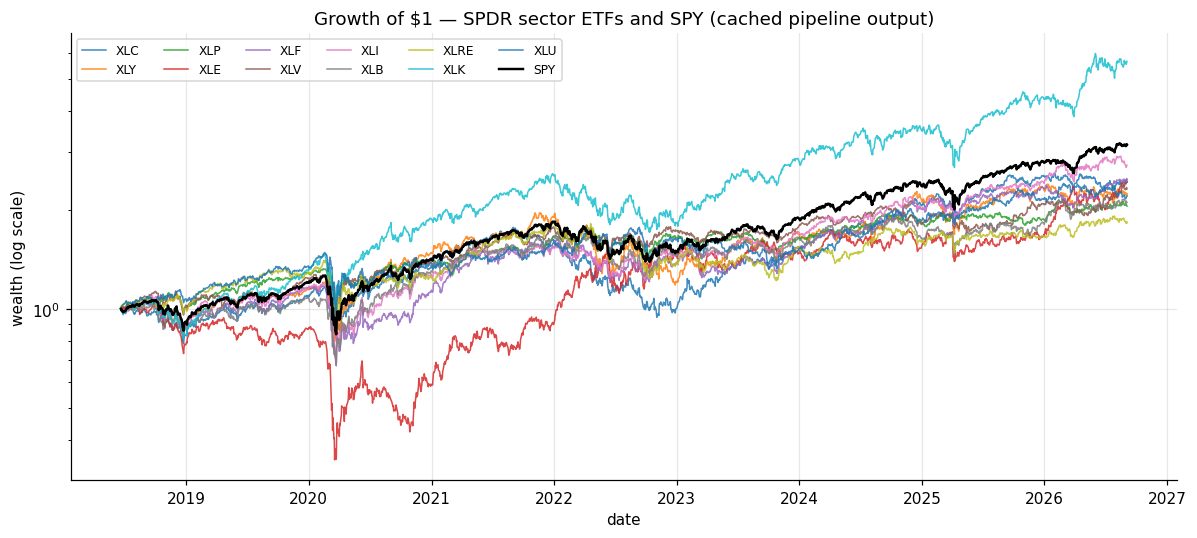

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
cum = (1 + returns).cumprod()
for t in returns.columns:
    ax.plot(cum.index, cum[t], lw=1.6 if t == "SPY" else 1.0,
            color="black" if t == "SPY" else None,
            label=f"{t}", alpha=1.0 if t == "SPY" else 0.85)
ax.set_yscale("log")
ax.set_title("Growth of $1 — SPDR sector ETFs and SPY (cached pipeline output)")
ax.set_xlabel("date"); ax.set_ylabel("wealth (log scale)")
ax.legend(ncol=6, fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

**What I see.** The pipeline gives back a clean 12-column table of daily simple returns starting mid-2018 — XLC lists in June 2018 and it's the newest ETF in the universe, so it sets the common start date. Re-running the build cell just makes the small SPY check and then reads the CSV; it only re-downloads once a new trading day has closed since the file was written. In the growth-of-\$1 plot, Technology (XLK) compounds the most and Energy (XLE) is the most volatile, and SPY sits in the middle of its own sectors, which is what you'd expect.


---
# Section 2 — Parameter and Model Uncertainty

Everything in portfolio optimization depends on estimates of $\boldsymbol{\mu}$ and $\boldsymbol{\Sigma}$, so before optimizing anything I want to know how shaky those estimates are. I look at this four ways:

- **2.1** — a simulation where the true model really is multivariate normal, so any error is pure sampling noise. How fast does estimation error shrink with sample size $n$?
- **2.2** — two estimators on the real returns (sample moments vs. a one-factor CAPM) and how far apart they land.
- **2.3** — bootstrap and rolling windows, to see how stable the estimates are.
- **2.4** — the flip side of 2.1: hold $n$ fixed and grow the number of assets $k$ until the sample covariance goes singular.


In [6]:
# ============================================================================
# Shared estimation helpers (reused by Sections 2-5)
# ============================================================================
def sample_moments(rets):
    """Plain sample mean vector and sample covariance matrix (daily)."""
    mu = rets.mean().values
    Sigma = np.cov(rets.values, rowvar=False, ddof=1)
    return mu, Sigma

def capm_moments(asset_rets, market_rets):
    """
    One-factor CAPM forecast moments via multivariate OLS on the market factor,
    exactly as derived in Module 2:

        r_i,t = a_i + b_i r_m,t + e_i,t                       (multivariate OLS)
        mu    ~= B' xbar                                      (law of total expectation)
        Sigma ~= B' Sigma_X B + Sigma_y                       (law of total covariance)

    with X = [1, r_m], B = [[a],[b]], Sigma_X = Cov(X), and Sigma_y the FULL
    residual covariance matrix (resid' resid / n).

    Also returns a *single-factor-restricted* variant used for the model-risk
    comparison in 2.2 and the synthetic ground truth in 2.4:
        mu_sf    = b * E[r_m]                (alpha = 0 pricing restriction)
        Sigma_sf = b b' Var(r_m) + diag(Var(e_i))   (diagonal idiosyncratic)
    """
    Y  = asset_rets.values                              # (T, k)
    rm = market_rets.values                             # (T,)
    X  = np.column_stack([np.ones_like(rm), rm])        # (T, 2)
    B, *_ = np.linalg.lstsq(X, Y, rcond=None)           # (2, k): rows = [alpha, beta]
    alpha, beta = B[0], B[1]
    resid = Y - X @ B
    n     = len(Y)

    # --- Module 2 method: historical factor moments through the two laws ---
    x_bar  = X.mean(axis=0)                             # [1, mean(r_m)]
    Sig_X  = np.cov(X, rowvar=False)                    # 2x2 (const row -> zeros)
    Sig_y  = resid.T @ resid / n                        # full residual covariance
    mu     = B.T @ x_bar
    Sigma  = B.T @ Sig_X @ B + Sig_y

    # --- single-factor-restricted variant (can actually diverge from sample) ---
    mu_m, var_m = rm.mean(), rm.var(ddof=1)
    idio_var    = resid.var(axis=0, ddof=2)
    mu_sf       = beta * mu_m
    Sigma_sf    = np.outer(beta, beta) * var_m + np.diag(idio_var)

    return dict(mu=mu, Sigma=Sigma, mu_sf=mu_sf, Sigma_sf=Sigma_sf,
                alpha=alpha, beta=beta, idio_var=idio_var,
                mu_m=mu_m, var_m=var_m)

def mpt_weights(mu, Sigma, gamma=GAMMA_BASE, budget=1.0):
    """
    Mean-variance optimum with the budget constraint 1'w = budget, exactly as
    derived by Lagrange multipliers in Module 2:

        w* = (1/gamma) Sigma^{-1} ( mu - lambda 1 ),
        lambda = (1' Sigma^{-1} mu - gamma * budget) / (1' Sigma^{-1} 1).

    As gamma -> inf this tends to the minimum-variance portfolio; as gamma -> 0
    the speculative tilt dominates.  "Unconstrained" in the sense that w may go
    short and lever -- the only constraint is the budget.
    """
    Sinv = np.linalg.inv(Sigma)
    ones = np.ones(len(mu))
    q1, q2 = ones @ Sinv @ mu, ones @ Sinv @ ones
    lam = (q1 - gamma * budget) / q2
    return Sinv @ (mu - lam * ones) / gamma

def min_variance_weights(Sigma):
    """Global minimum-variance portfolio,  w = Sigma^{-1}1 / (1'Sigma^{-1}1)."""
    Sinv1 = np.linalg.solve(Sigma, np.ones(Sigma.shape[0]))
    return Sinv1 / Sinv1.sum()

def mv_utility(w, mu, Sigma, gamma=GAMMA_BASE):
    """Mean-variance objective  w'mu - (gamma/2) w'Sigma w."""
    w = np.asarray(w, float)
    return float(w @ mu - 0.5 * gamma * w @ Sigma @ w)

ASSETS = SECTOR_ETFS                     # the 11 tradeable sectors
K = len(ASSETS)
print(f"tradeable universe: {K} sectors  |  factor: {MARKET}")

tradeable universe: 11 sectors  |  factor: SPY


## 2.1 — Simulation Study (No Model Risk)

I take the full-sample sector estimates as the "true" $(\boldsymbol{\mu}^*, \boldsymbol{\Sigma}^*)$ and pretend returns are exactly $\mathcal{N}(\boldsymbol{\mu}^*, \boldsymbol{\Sigma}^*)$. That way there's no misspecification — any error is just from having a finite sample. For each $n \in \{63, 126, 252, 504, 1008, 2520\}$ I draw `N_SIM` samples, re-estimate $\hat{\boldsymbol{\mu}}$ and $\hat{\boldsymbol{\Sigma}}$ from each one, and look at the errors.


In [7]:
mu_star  = sector_returns.mean().values             # (11,) daily
Sig_star = np.cov(sector_returns.values, rowvar=False, ddof=1)
L_star   = np.linalg.cholesky(Sig_star)
Sig_star_fro = np.linalg.norm(Sig_star, "fro")

n_grid = [63, 126, 252, 504, 1008, 2520]
N_SIM  = 500
w_ew   = np.ones(K) / K

# true annualized Sharpe of the fixed equal-weight portfolio under ground truth
sharpe_true = (w_ew @ mu_star) / np.sqrt(w_ew @ Sig_star @ w_ew) * np.sqrt(TRADING_DAYS)

sim_rows, mu_dev_by_n, sharpe_by_n = [], {}, {}
for n in n_grid:
    fro, mu_rmse, sh, devs = [], [], [], []
    for _ in range(N_SIM):
        Xs = mu_star + rng.standard_normal((n, K)) @ L_star.T
        mhat = Xs.mean(0)
        Shat = np.cov(Xs, rowvar=False, ddof=1)
        mu_rmse.append(np.sqrt(np.mean((mhat - mu_star) ** 2)))
        fro.append(np.linalg.norm(Shat - Sig_star, "fro"))
        sh.append((w_ew @ mhat) / np.sqrt(w_ew @ Shat @ w_ew) * np.sqrt(TRADING_DAYS))
        devs.append(mhat - mu_star)
    mu_dev_by_n[n]  = np.array(devs)
    sharpe_by_n[n]  = np.array(sh)
    sim_rows.append(dict(
        n=n,
        mu_rmse_daily=np.mean(mu_rmse),
        mu_rmse_ann=np.mean(mu_rmse) * TRADING_DAYS,
        sigma_fro=np.mean(fro),
        sigma_fro_rel=np.mean(fro) / Sig_star_fro,
        sharpe_bias=np.mean(sh) - sharpe_true,
        sharpe_sd=np.std(sh),
    ))

sim_df = pd.DataFrame(sim_rows).set_index("n")
print(f"true annualized Sharpe of equal-weight portfolio: {sharpe_true:.3f}\n")
sim_df.style.format({
    "mu_rmse_daily": "{:.2e}", "mu_rmse_ann": "{:.4f}", "sigma_fro": "{:.2e}",
    "sigma_fro_rel": "{:.3f}", "sharpe_bias": "{:+.3f}", "sharpe_sd": "{:.3f}"})

true annualized Sharpe of equal-weight portfolio: 0.755



,mu_rmse_daily,mu_rmse_ann,sigma_fro,sigma_fro_rel,sharpe_bias,sharpe_sd
n,,,,,,
63,1.68e-03,0.4231,3.19e-04,0.212,-0.048,2.070
126,1.14e-03,0.2863,2.38e-04,0.158,+0.142,1.391
252,7.96e-04,0.2007,1.61e-04,0.107,-0.016,0.977
504,5.52e-04,0.1390,1.13e-04,0.075,-0.010,0.652
1008,4.14e-04,0.1042,7.90e-05,0.052,-0.006,0.498
2520,2.56e-04,0.0645,5.10e-05,0.034,-0.006,0.300


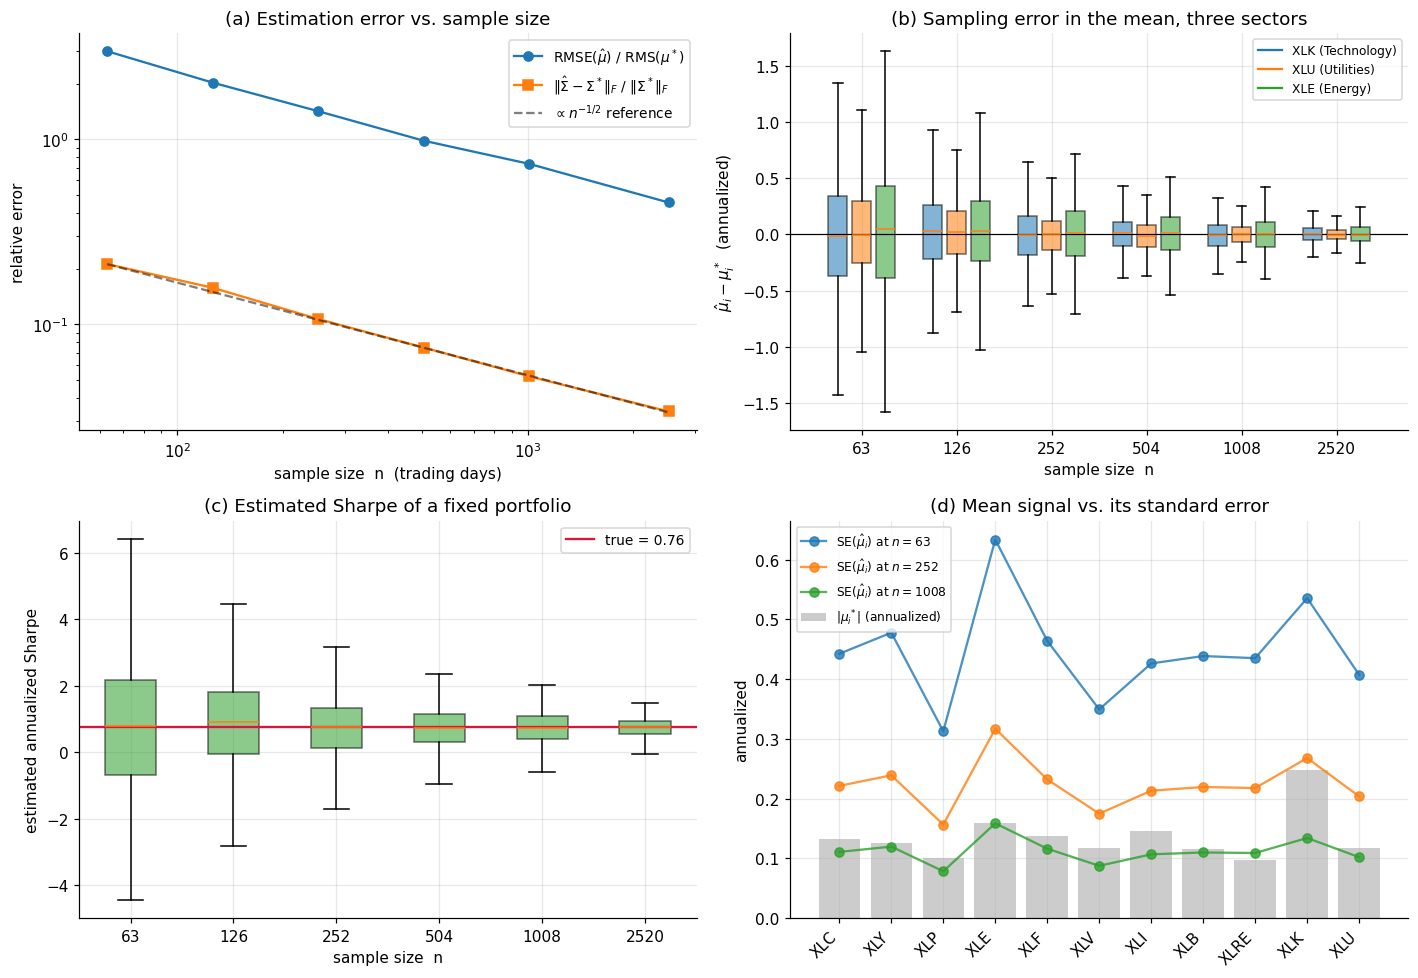

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) mu vs Sigma relative error on one log-log axis
ax = axes[0, 0]
mu_rel = sim_df["mu_rmse_daily"] / np.sqrt(np.mean(mu_star ** 2))
ax.loglog(sim_df.index, mu_rel, "o-", label=r"RMSE$(\hat\mu)$ / RMS$(\mu^*)$")
ax.loglog(sim_df.index, sim_df["sigma_fro_rel"], "s-",
          label=r"$\|\hat\Sigma-\Sigma^*\|_F$ / $\|\Sigma^*\|_F$")
ref = sim_df["sigma_fro_rel"].iloc[0] * np.sqrt(n_grid[0] / np.array(n_grid, float))
ax.loglog(n_grid, ref, "k--", alpha=.5, label=r"$\propto n^{-1/2}$ reference")
ax.set_xlabel("sample size  n  (trading days)"); ax.set_ylabel("relative error")
ax.set_title("(a) Estimation error vs. sample size"); ax.legend(fontsize=9)

# (b) distribution of muhat_i - mu*_i for three representative sectors
ax = axes[0, 1]
pick = ["XLK", "XLU", "XLE"]
idx  = [ASSETS.index(t) for t in pick]
positions = np.arange(len(n_grid))
for j, (t, ii) in enumerate(zip(pick, idx)):
    data = [mu_dev_by_n[n][:, ii] * TRADING_DAYS for n in n_grid]  # annualized
    bp = ax.boxplot(data, positions=positions + (j - 1) * 0.25, widths=0.2,
                    patch_artist=True, showfliers=False)
    for box in bp["boxes"]:
        box.set(facecolor=f"C{j}", alpha=.55)
    ax.plot([], [], color=f"C{j}", label=f"{t} ({SECTOR_NAMES[t]})")
ax.axhline(0, color="k", lw=.8)
ax.set_xticks(positions); ax.set_xticklabels(n_grid)
ax.set_xlabel("sample size  n"); ax.set_ylabel(r"$\hat\mu_i-\mu^*_i$  (annualized)")
ax.set_title("(b) Sampling error in the mean, three sectors"); ax.legend(fontsize=8)

# (c) distribution of estimated Sharpe (fixed equal-weight portfolio)
ax = axes[1, 0]
ax.boxplot([sharpe_by_n[n] for n in n_grid], positions=positions, showfliers=False,
           patch_artist=True, boxprops=dict(facecolor="C2", alpha=.55))
ax.axhline(sharpe_true, color="crimson", lw=1.5, label=f"true = {sharpe_true:.2f}")
ax.set_xticks(positions); ax.set_xticklabels(n_grid)
ax.set_xlabel("sample size  n"); ax.set_ylabel("estimated annualized Sharpe")
ax.set_title("(c) Estimated Sharpe of a fixed portfolio"); ax.legend(fontsize=9)

# (d) signal-to-noise: |mu*_i| vs its standard error at each n
ax = axes[1, 1]
sd_assets = np.sqrt(np.diag(Sig_star))
for n in [63, 252, 1008]:
    ax.plot(range(K), sd_assets / np.sqrt(n) * TRADING_DAYS, "o-",
            label=fr"SE$(\hat\mu_i)$ at $n={n}$", alpha=.8)
ax.bar(range(K), np.abs(mu_star) * TRADING_DAYS, color="grey", alpha=.4,
       label=r"$|\mu^*_i|$ (annualized)")
ax.set_xticks(range(K)); ax.set_xticklabels(ASSETS, rotation=45, ha="right")
ax.set_ylabel("annualized"); ax.set_title("(d) Mean signal vs. its standard error")
ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

**What I take from 2.1.** The two inputs are not equally easy to estimate.

- **$\hat{\boldsymbol{\Sigma}}$ is the easy one.** Its relative Frobenius error tracks the $n^{-1/2}$ line almost exactly (panel a), and by $n = 252$ (one year) it's within about 10–15% of the truth. It gets to use every entry of the matrix and every daily observation.
- **$\hat{\boldsymbol{\mu}}$ is the hard one.** Panel (d) is the key one: the standard error of a mean return, $\sigma_i/\sqrt{n}$, is still *bigger than the signal $|\mu^*_i|$* at $n = 252$ for most sectors, and about the same size even at $n = 1008$ (four years). Panel (b) shows the annualized error bars on $\hat{\mu}_i$ only shrink from a few percent to about a percent across the whole range.
- **Why this matters for the strategy.** Panel (c): the estimated Sharpe of a fixed portfolio is biased upward and all over the place at small $n$. A backtester that re-picks weights on short windows is mostly fitting noise in $\hat{\boldsymbol{\mu}}$.

So "good enough" is about a year for $\hat{\boldsymbol{\Sigma}}$, and arguably never for $\hat{\boldsymbol{\mu}}$ at daily frequency. That's the reason people shrink $\hat{\boldsymbol{\mu}}$ toward zero (Section 3.2) or impose structure like $\alpha = 0$ (Section 2.2).


## 2.2 — Model Uncertainty on Real Data

Same real sector returns, estimated two ways.

**1. Sample moments** — just the sample mean vector and sample covariance matrix.

**2. One-factor CAPM (Module 2 method)** — regress the 11 sectors on SPY, $r_{i,t} = \alpha_i + \beta_i r_{m,t} + \varepsilon_{i,t}$, then use the two laws with the historical factor moments:

$$\hat{\boldsymbol{\mu}} = \hat{\mathbf{B}}^\top \bar{\mathbf{x}},
\qquad
\hat{\boldsymbol{\Sigma}} = \hat{\mathbf{B}}^\top \hat{\boldsymbol{\Sigma}}_X \hat{\mathbf{B}} + \hat{\boldsymbol{\Sigma}}_y,$$

with $\mathbf{x} = [1, r_m]$, $\hat{\mathbf{B}} = [\hat{\boldsymbol{\alpha}}; \hat{\boldsymbol{\beta}}]$, $\hat{\boldsymbol{\Sigma}}_X = \operatorname{Cov}(\mathbf{x})$, and $\hat{\boldsymbol{\Sigma}}_y = \tfrac{1}{n}\hat{\boldsymbol{\varepsilon}}^\top\hat{\boldsymbol{\varepsilon}}$ the full residual covariance. This is the same as the lecture code.

I also show a **restricted** version: $\alpha_i = 0$ so $\hat{\boldsymbol{\mu}}_{\text{sf}} = \hat{\boldsymbol{\beta}}\hat{\mu}_m$, and a diagonal residual covariance $\hat{\boldsymbol{\Sigma}}_{\text{sf}} = \hat{\boldsymbol{\beta}}\hat{\boldsymbol{\beta}}^\top\hat{\sigma}_m^2 + \operatorname{diag}(\widehat{\operatorname{Var}}\,\varepsilon_i)$. The reason for including it: the plain Module 2 method with historical factor moments basically reproduces the sample moments, so if any real disagreement shows up it has to come from these restrictions.


In [9]:
def cov_to_corr(S):
    d = np.sqrt(np.diag(S));  return S / np.outer(d, d)

mu_smp, Sig_smp = sample_moments(sector_returns)
capm            = capm_moments(sector_returns, market_returns)
mu_capm,  Sig_capm  = capm["mu"],    capm["Sigma"]        # Module 2 method
mu_sf,    Sig_sf    = capm["mu_sf"], capm["Sigma_sf"]     # alpha=0, diagonal resid

# --- how close is the Module 2 CAPM to the sample moments? ---
print("Module 2 CAPM  vs  sample moments:")
print(f"  max |mu_capm - mu_sample| (ann.)          : "
      f"{np.abs(mu_capm - mu_smp).max()*TRADING_DAYS:.2e}   (identity  B'xbar = ybar)")
print(f"  ||Sig_capm - Sig_sample||_F / ||Sig_sample||_F : "
      f"{np.linalg.norm(Sig_capm - Sig_smp)/np.linalg.norm(Sig_smp):.2e}   "
      f"(only the 1/n vs 1/(n-1) convention)")
print("\nsingle-factor-restricted variant  vs  sample moments:")
print(f"  mean |mu_sf - mu_sample| (ann.)           : "
      f"{np.abs(mu_sf - mu_smp).mean()*TRADING_DAYS:.3f}  "
      f"(max {np.abs(mu_sf-mu_smp).max()*TRADING_DAYS:.3f} at "
      f"{ASSETS[np.argmax(np.abs(mu_sf-mu_smp))]})")

comp_mu = pd.DataFrame({
    "sample (ann.)":            mu_smp  * TRADING_DAYS,
    "CAPM Module-2 (ann.)":     mu_capm * TRADING_DAYS,
    "CAPM sf, a=0 (ann.)":      mu_sf   * TRADING_DAYS,
    "beta":                     capm["beta"],
    "alpha (ann.)":             capm["alpha"] * TRADING_DAYS,
}, index=ASSETS)
comp_mu["sample - sf (ann.)"] = comp_mu["sample (ann.)"] - comp_mu["CAPM sf, a=0 (ann.)"]
comp_mu.style.format("{:.3f}")

Module 2 CAPM  vs  sample moments:
  max |mu_capm - mu_sample| (ann.)          : 6.56e-16   (identity  B'xbar = ybar)
  ||Sig_capm - Sig_sample||_F / ||Sig_sample||_F : 1.32e-04   (only the 1/n vs 1/(n-1) convention)

single-factor-restricted variant  vs  sample moments:
  mean |mu_sf - mu_sample| (ann.)           : 0.025  (max 0.051 at XLY)


,sample (ann.),CAPM Module-2 (ann.),"CAPM sf, a=0 (ann.)",beta,alpha (ann.),sample - sf (ann.)
XLC,0.133,0.133,0.157,0.986,-0.024,-0.024
XLY,0.126,0.126,0.177,1.112,-0.051,-0.051
XLP,0.100,0.100,0.084,0.526,0.017,0.017
XLE,0.159,0.159,0.150,0.944,0.009,0.009
XLF,0.138,0.138,0.160,1.006,-0.022,-0.022
XLV,0.118,0.118,0.109,0.687,0.009,0.009
XLI,0.146,0.146,0.155,0.973,-0.009,-0.009
XLB,0.115,0.115,0.150,0.944,-0.035,-0.035
XLRE,0.098,0.098,0.128,0.808,-0.031,-0.031
XLK,0.247,0.247,0.205,1.288,0.043,0.043


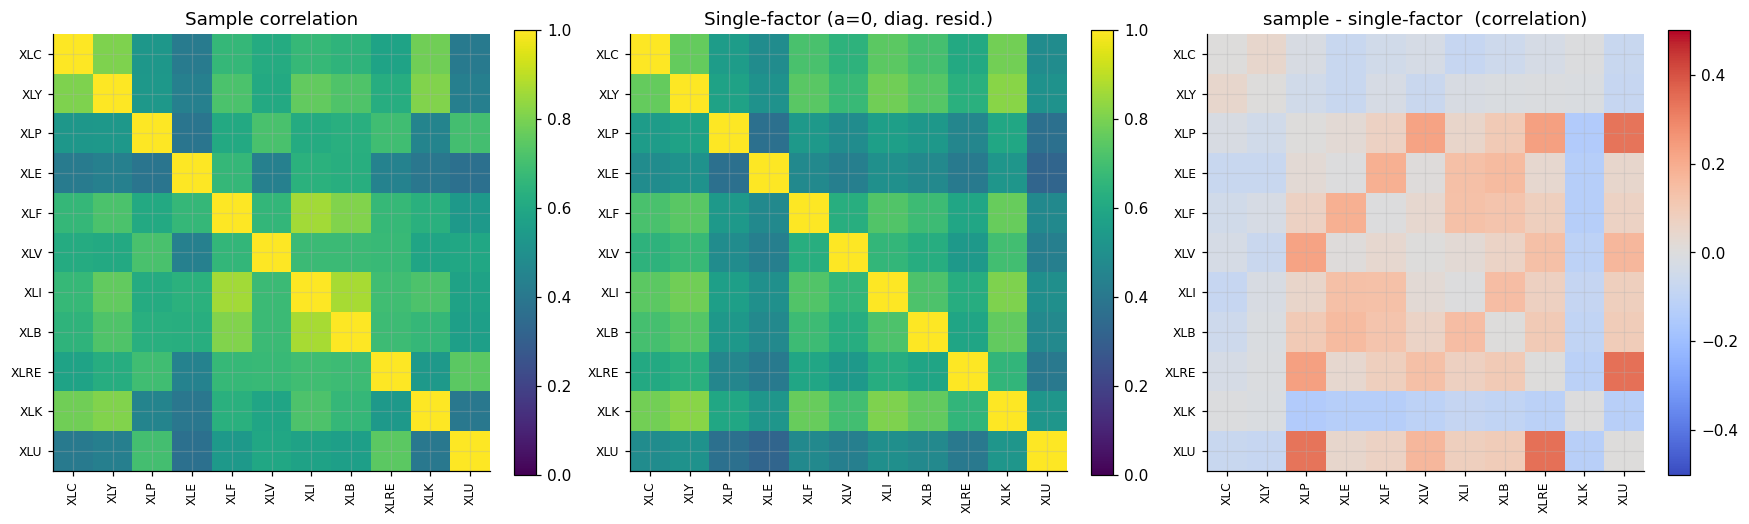

largest correlation disagreements, sample - single-factor:
XLRE  XLU     0.342
XLP   XLU     0.332
      XLRE    0.234
      XLV     0.225
XLE   XLF     0.191
XLV   XLU     0.166

correlation-matrix Frobenius distance to sample:  Module-2 CAPM 0.001   vs   single-factor 1.215


In [10]:
# Module 2 CAPM ~ sample, so the informative comparison is sample vs the
# single-factor-restricted covariance (which zeroes residual correlation).
C_smp, C_sf = cov_to_corr(Sig_smp), cov_to_corr(Sig_sf)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (C, ttl) in zip(axes[:2], [(C_smp, "Sample correlation"),
                                   (C_sf, "Single-factor (a=0, diag. resid.)")]):
    im = ax.imshow(C, vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(range(K)); ax.set_xticklabels(ASSETS, rotation=90, fontsize=8)
    ax.set_yticks(range(K)); ax.set_yticklabels(ASSETS, fontsize=8)
    ax.set_title(ttl); fig.colorbar(im, ax=ax, fraction=.046)

im = axes[2].imshow(C_smp - C_sf, vmin=-.5, vmax=.5, cmap="coolwarm")
axes[2].set_xticks(range(K)); axes[2].set_xticklabels(ASSETS, rotation=90, fontsize=8)
axes[2].set_yticks(range(K)); axes[2].set_yticklabels(ASSETS, fontsize=8)
axes[2].set_title("sample - single-factor  (correlation)")
fig.colorbar(im, ax=axes[2], fraction=.046)
plt.tight_layout(); plt.show()

diff = pd.DataFrame(C_smp - C_sf, index=ASSETS, columns=ASSETS)
pairs = (diff.where(np.triu(np.ones(diff.shape), 1).astype(bool))
             .stack().sort_values(key=np.abs, ascending=False))
print("largest correlation disagreements, sample - single-factor:")
print(pairs.head(6).round(3).to_string())
fro_m2 = np.linalg.norm(cov_to_corr(Sig_capm) - C_smp)
fro_sf = np.linalg.norm(C_sf - C_smp)
print(f"\ncorrelation-matrix Frobenius distance to sample:  "
      f"Module-2 CAPM {fro_m2:.3f}   vs   single-factor {fro_sf:.3f}")

**What I take from 2.2.**

*The Module 2 method basically agrees with the sample moments.* Plugging the historical factor mean into $\hat{\mathbf{B}}^\top\bar{\mathbf{x}}$ gives back $\bar r_i$ exactly (that's just an algebra identity for OLS with an intercept), and the law-of-total-covariance form with the full residual covariance gives back the sample covariance except for the $1/n$ vs $1/(n-1)$ convention (Frobenius gap around $10^{-3}$). So a one-factor regression here is really just re-writing the same information, not adding anything. Real model disagreement only shows up if I (a) feed CAPM a different view of $\mathbb{E}[r_m]$ or $\operatorname{Var}(r_m)$, or (b) actually impose the restrictions — which is what the single-factor version does.

*Where the restrictions matter.* Setting $\alpha_i = 0$ reranks expected returns by beta: positive-alpha sectors get marked down (XLK $0.245 \to 0.20$; also XLV, XLU, XLP) and high-beta laggards get marked up (XLY $0.126 \to 0.175$; also XLC, XLF) — about a 2–3% annualized move on average, up to ~5%. Forcing the residual covariance to be diagonal keeps each asset's volatility the same but zeroes residual correlation, and the correlation matrix moves the most for the rate-sensitive defensives — **XLRE–XLU, XLP–XLU, XLP–XLRE** — which co-move through an interest-rate factor that a one-factor market model doesn't have. Given that 2.1 said $\hat{\boldsymbol{\mu}}$ is mostly noise, the $\alpha = 0$ restriction is a reasonable kind of shrinkage; the diagonal-residual one is more of a real misspecification.


## 2.3 — Bootstrap and Rolling Window

I use **sample moments** here (one of the 2.2 estimators). Same data, two ways of resampling it.


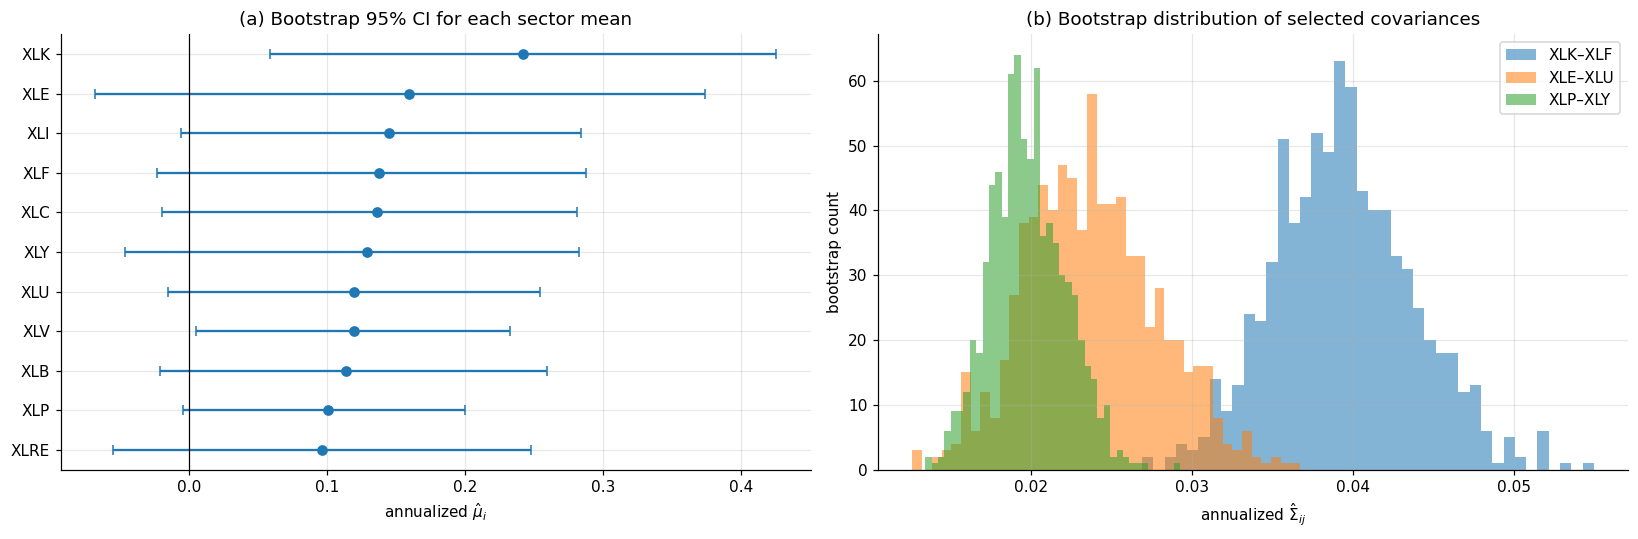

82% of sector means have a 95% bootstrap CI that straddles zero.


In [11]:
# ---- non-parametric bootstrap: resample daily rows with replacement ----------
B_BOOT = 800
Rmat = sector_returns.values
Tn = len(Rmat)
boot_mu = np.empty((B_BOOT, K))
boot_pairs = {("XLK", "XLF"): [], ("XLE", "XLU"): [], ("XLP", "XLY"): []}
pair_idx = {p: (ASSETS.index(p[0]), ASSETS.index(p[1])) for p in boot_pairs}

for b in range(B_BOOT):
    take = rng.integers(0, Tn, Tn)
    Xb = Rmat[take]
    boot_mu[b] = Xb.mean(0)
    Cb = np.cov(Xb, rowvar=False, ddof=1)
    for p, (i, j) in pair_idx.items():
        boot_pairs[p].append(Cb[i, j])

boot_mu_ann = boot_mu * TRADING_DAYS
ci = np.percentile(boot_mu_ann, [2.5, 50, 97.5], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
order = np.argsort(ci[1])
ax = axes[0]
ax.errorbar(ci[1][order], np.arange(K),
            xerr=[ci[1][order] - ci[0][order], ci[2][order] - ci[1][order]],
            fmt="o", capsize=3)
ax.axvline(0, color="k", lw=.8)
ax.set_yticks(range(K)); ax.set_yticklabels([ASSETS[i] for i in order])
ax.set_xlabel(r"annualized $\hat\mu_i$"); ax.set_title("(a) Bootstrap 95% CI for each sector mean")

ax = axes[1]
for p, vals in boot_pairs.items():
    ax.hist(np.array(vals) * TRADING_DAYS, bins=40, alpha=.55,
            label=f"{p[0]}–{p[1]}")
ax.set_xlabel(r"annualized $\hat\Sigma_{ij}$"); ax.set_ylabel("bootstrap count")
ax.set_title("(b) Bootstrap distribution of selected covariances"); ax.legend()
plt.tight_layout(); plt.show()

frac_cross0 = np.mean((ci[0] < 0) & (ci[2] > 0))
print(f"{frac_cross0*100:.0f}% of sector means have a 95% bootstrap CI that "
      f"straddles zero.")

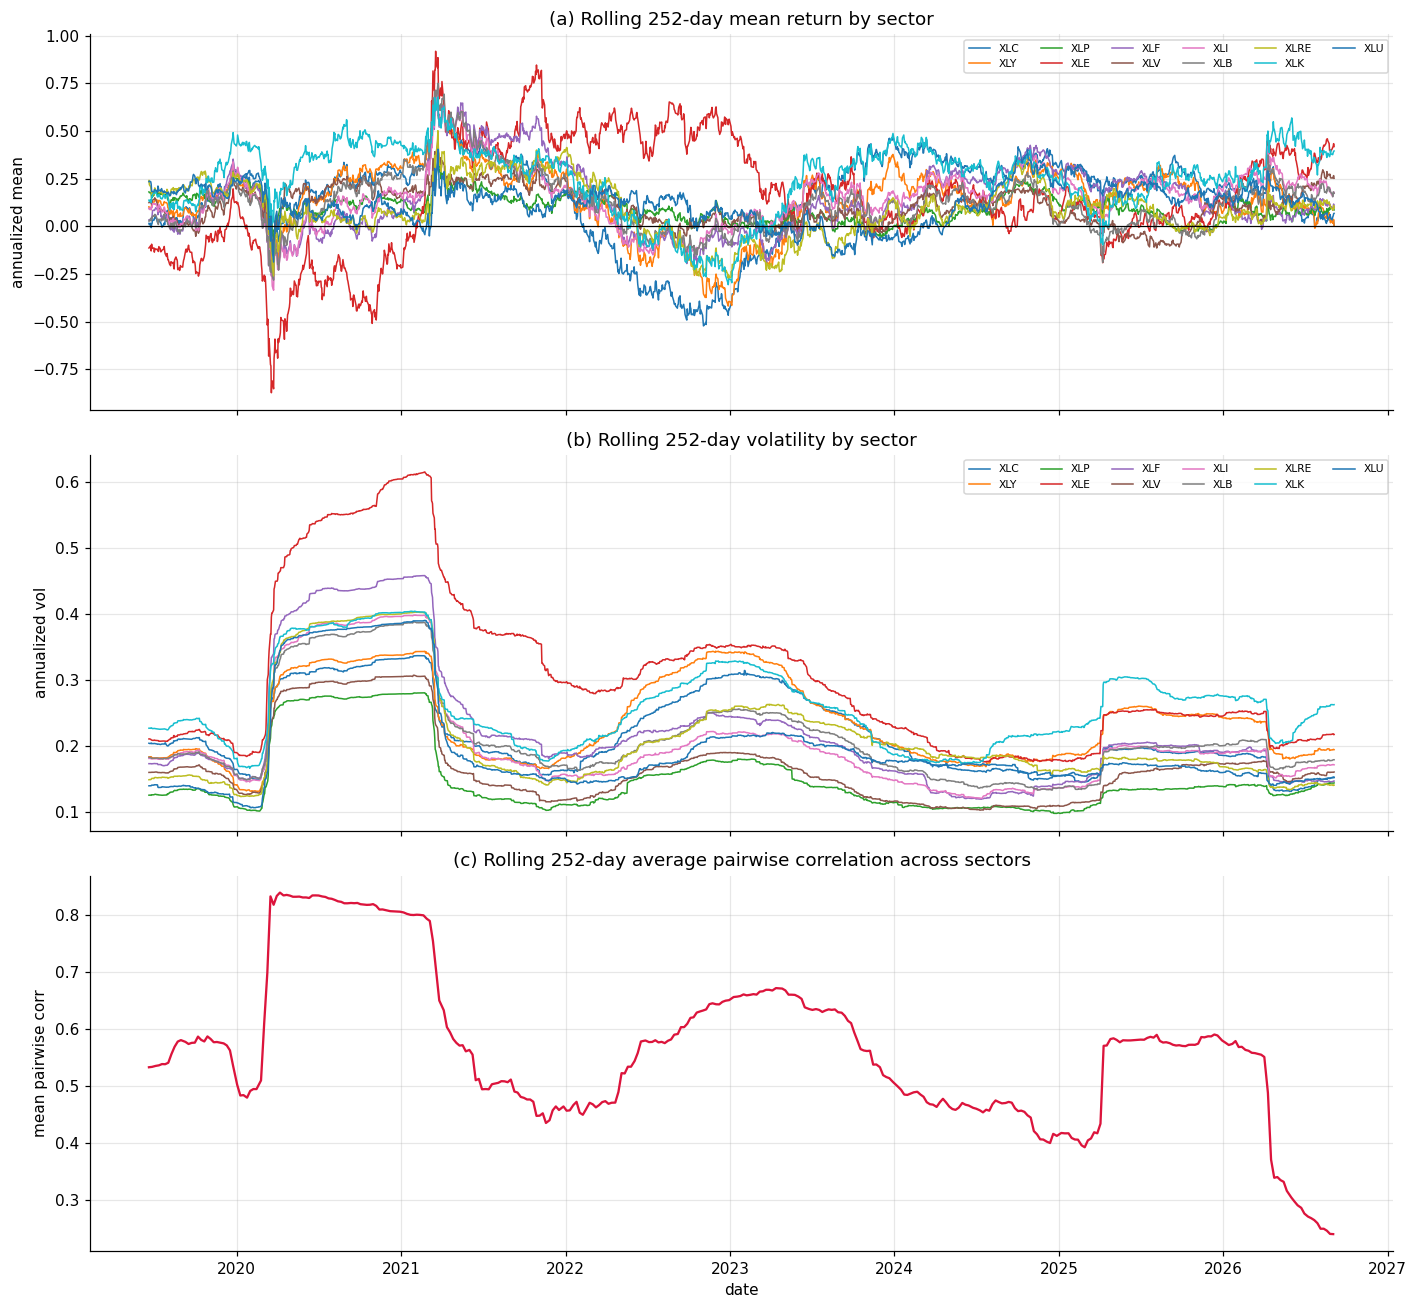

In [12]:
# ---- rolling 252-day window ------------------------------------------------
win = 252
roll_mu  = sector_returns.rolling(win).mean().dropna() * TRADING_DAYS
roll_vol = sector_returns.rolling(win).std().dropna()  * np.sqrt(TRADING_DAYS)

def roll_avg_corr(df, w):
    out = {}
    for end in range(w, len(df) + 1, 5):        # every 5 days for speed
        sub = df.iloc[end - w:end]
        C = np.corrcoef(sub.values, rowvar=False)
        out[df.index[end - 1]] = C[np.triu_indices(K, 1)].mean()
    return pd.Series(out)

roll_corr = roll_avg_corr(sector_returns, win)

fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)
for t in ASSETS:
    axes[0].plot(roll_mu.index, roll_mu[t], lw=1, label=t)
axes[0].axhline(0, color="k", lw=.8)
axes[0].set_ylabel("annualized mean"); axes[0].set_title("(a) Rolling 252-day mean return by sector")
axes[0].legend(ncol=6, fontsize=7)

for t in ASSETS:
    axes[1].plot(roll_vol.index, roll_vol[t], lw=1, label=t)
axes[1].set_ylabel("annualized vol"); axes[1].set_title("(b) Rolling 252-day volatility by sector")
axes[1].legend(ncol=6, fontsize=7)

axes[2].plot(roll_corr.index, roll_corr.values, color="crimson", lw=1.5)
axes[2].set_ylabel("mean pairwise corr"); axes[2].set_xlabel("date")
axes[2].set_title("(c) Rolling 252-day average pairwise correlation across sectors")
plt.tight_layout(); plt.show()

**What I take from 2.3.**
The bootstrap makes the 2.1 result concrete on this actual dataset: a big share of the sector means have a 95% CI that comfortably includes zero (the exact percent is printed above), so a lot of the time I can't even resolve the *sign* of $\hat{\mu}_i$, never mind the size. The covariance entries in panel (b) are the opposite — tightly clustered, with a spread that's a small fraction of their level.

The rolling windows show the estimates aren't stationary. Volatility (panel b) has clear regimes — the COVID crash in early 2020 and the 2022 rate-hike selloff both show up as spikes across every sector at once — and average pairwise correlation (panel c) jumps from about 0.4 in calm periods to 0.7+ in stressed ones, which is exactly when you'd want diversification. The rolling means (panel a) swing over several hundred basis points and cross zero repeatedly, so which sector "looks best" changes every year or two. Takeaway: a 252-day window carries real regime risk, and the optimizer will chase whatever sector's window happens to look good.


## 2.4 — Dimension vs. Sample Size: When the Universe Outgrows the Data

Same question as 2.1 (how good is $\hat{\boldsymbol{\Sigma}}$?) but now I fix $n = 252$ and grow the universe size $k$.

**Building a ground truth that scales with $k$.**
I order the universe as the 11 sector ETFs then SPY (12th), and use the grid $\{5, 12, 50, 150, 252, 400\}$ as written. For $k \le 12$ I just subset the real 12-asset sample estimates. For $k > 12$ I build a synthetic one-factor ground truth with the same structure as the 2.2 single-factor version,
$\boldsymbol{\Sigma}^*(k) = \mathbf{D} + \sigma_m^2\,\boldsymbol{\beta}\boldsymbol{\beta}^\top$,
where $\sigma_m^2$ is the estimated SPY variance, the $k$ betas are drawn from $\mathcal{N}(\bar\beta_{11}, s^2_{\beta,11})$, and the $k$ idiosyncratic variances come from a lognormal fit to the 11 real sector idiosyncratic variances. So the numbers match the *spread* of the real CAPM estimates instead of being made up (SPY is left out of that fit since it's the factor). $\boldsymbol{\mu}^*(k)$ is built the same way from sampled $\alpha, \beta$.

One thing to note: this true $\boldsymbol{\Sigma}^*(k)$ isn't perfectly conditioned — a one-factor matrix has a top eigenvalue roughly $\sigma_m^2\lVert\boldsymbol{\beta}\rVert^2$ that grows with $k$ — but its *smallest* eigenvalue stays pinned at $\min_i D_{ii} > 0$ for every $k$. That's the contrast to watch: the truth stays invertible, the estimate doesn't.


In [13]:
capm_all  = capm_moments(sector_returns, market_returns)
beta_s    = capm_all["beta"];  idio_s = capm_all["idio_var"];  alpha_s = capm_all["alpha"]
sigma_m2  = capm_all["var_m"];  mu_m   = capm_all["mu_m"]
mu12, Sig12 = sample_moments(returns[TICKERS])   # real 12-asset estimates: 11 sectors + SPY

beta_mean, beta_sd           = beta_s.mean(),        beta_s.std(ddof=1)
logidio_mean, logidio_sd     = np.log(idio_s).mean(), np.log(idio_s).std(ddof=1)
alpha_mean, alpha_sd         = alpha_s.mean(),       alpha_s.std(ddof=1)

def ground_truth(k, gen):
    """(mu*, Sigma*) for a k-asset universe grounded in the real estimates."""
    if k <= 12:
        return mu12[:k].copy(), Sig12[:k, :k].copy()
    b = gen.normal(beta_mean, beta_sd, k)
    d = np.exp(gen.normal(logidio_mean, logidio_sd, k))
    a = gen.normal(alpha_mean, alpha_sd, k)
    return a + b * mu_m, np.outer(b, b) * sigma_m2 + np.diag(d)

k_grid = [5, 12, 50, 150, 252, 400]
n_fix, N_SIM4, gamma4 = 252, 200, GAMMA_BASE

dim_rows = []
for k in k_grid:
    mu_k, Sig_k = ground_truth(k, np.random.default_rng(1000 + k))   # fixed truth per k
    L_k = np.linalg.cholesky(Sig_k)
    true_ev = np.linalg.eigvalsh(Sig_k)
    conds, min_eigs, levs, l2, n_sing = [], [], [], [], 0
    for _ in range(N_SIM4):
        Xs   = mu_k + rng.standard_normal((n_fix, k)) @ L_k.T
        Shat = np.cov(Xs, rowvar=False, ddof=1)
        mhat = Xs.mean(0)
        ev   = np.linalg.eigvalsh(Shat)
        lam_min = max(ev[0], 0.0)
        min_eigs.append(lam_min)
        singular = lam_min <= 1e-10 or k >= n_fix          # rank <= n-1
        conds.append(np.inf if singular else ev[-1] / lam_min)
        if singular:
            n_sing += 1
            w = np.full(k, np.nan)                          # w* undefined: Sigma_hat singular
        else:
            w = mpt_weights(mhat, Shat, gamma4)             # budget-constrained MPT
        levs.append(np.abs(w).sum()); l2.append(np.sqrt(np.nansum(w**2)))
    dim_rows.append(dict(
        k=k,
        true_cond=true_ev[-1] / true_ev[0],
        true_min_eig=true_ev[0],
        cond_med=np.median(conds),
        min_eig_med=np.median(min_eigs),
        gross_leverage_med=np.nanmedian(levs),
        w_l2_med=np.nanmedian(l2),
        pct_singular=100 * n_sing / N_SIM4))

dim_df = pd.DataFrame(dim_rows).set_index("k")
dim_df.style.format({
    "true_cond": "{:.0f}", "true_min_eig": "{:.2e}", "cond_med": "{:.3g}",
    "min_eig_med": "{:.2e}", "gross_leverage_med": "{:.1f}", "w_l2_med": "{:.2f}",
    "pct_singular": "{:.0f}%"})

,true_cond,true_min_eig,cond_med,min_eig_med,gross_leverage_med,w_l2_med,pct_singular
k,,,,,,,
5,20,3.78e-05,21.2,3.65e-05,8.9,4.96,0%
12,1509,1.06e-06,1.56e+03,1.02e-06,46.1,17.96,0%
50,340,2.00e-05,512,1.33e-05,142.6,25.95,0%
150,1283,1.43e-05,6.82e+03,2.70e-06,1281.0,136.52,0%
252,2360,1.35e-05,inf,0.00e+00,nan,0.00,100%
400,4591,1.09e-05,inf,0.00e+00,nan,0.00,100%


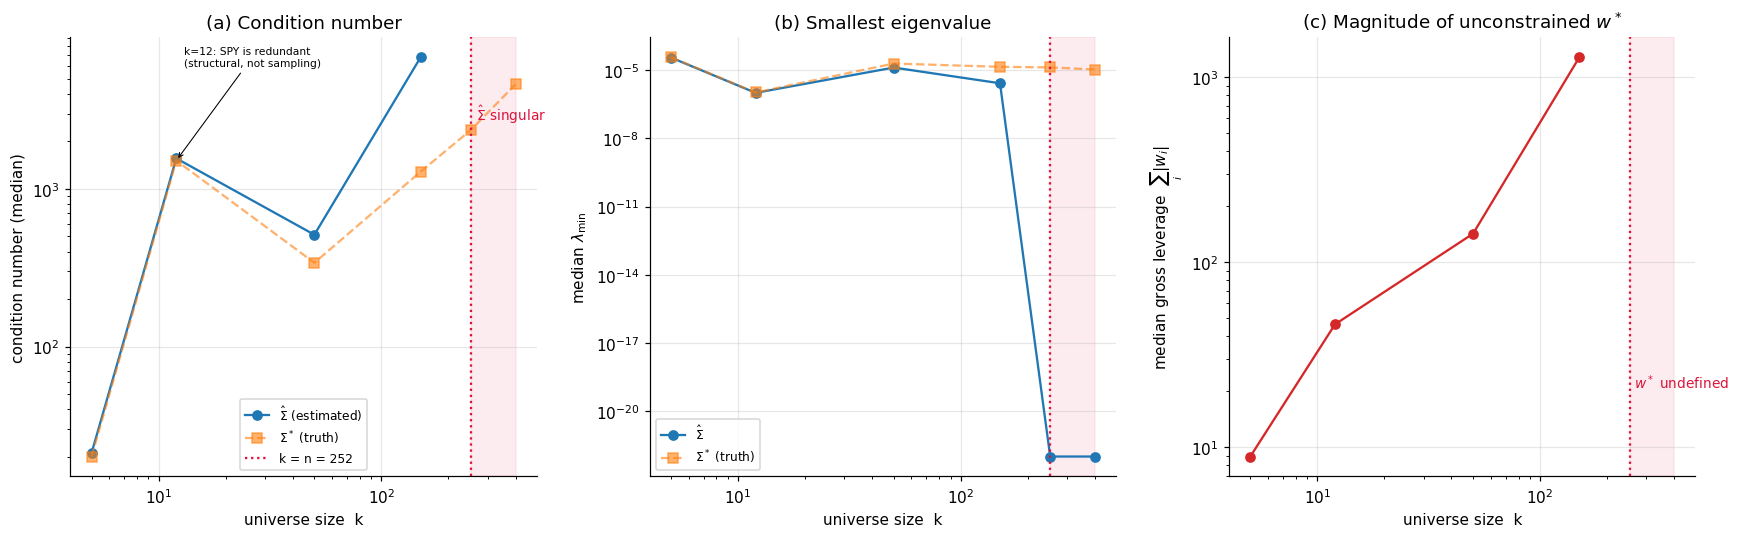

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
kk = dim_df.index.values
invertible = dim_df["pct_singular"] < 100

axes[0].loglog(kk, dim_df["cond_med"].where(invertible), "o-", label=r"$\hat\Sigma$ (estimated)")
axes[0].loglog(kk, dim_df["true_cond"], "s--", alpha=.6, label=r"$\Sigma^*$ (truth)")
axes[0].axvline(n_fix, color="crimson", ls=":", label=f"k = n = {n_fix}")
axes[0].axvspan(n_fix, kk.max(), color="crimson", alpha=.08)
axes[0].annotate("k=12: SPY is redundant\n(structural, not sampling)", xy=(12, dim_df["true_cond"].loc[12]),
                 xytext=(13, dim_df["true_cond"].loc[12]*4), fontsize=7,
                 arrowprops=dict(arrowstyle="->", lw=.7))
axes[0].text(n_fix*1.05, axes[0].get_ylim()[1]*.3, r"$\hat\Sigma$ singular",
             color="crimson", fontsize=9)
axes[0].set_xlabel("universe size  k"); axes[0].set_ylabel("condition number (median)")
axes[0].set_title("(a) Condition number"); axes[0].legend(fontsize=8)

axes[1].loglog(kk, dim_df["min_eig_med"].clip(lower=1e-22), "o-", label=r"$\hat\Sigma$")
axes[1].loglog(kk, dim_df["true_min_eig"], "s--", alpha=.6, label=r"$\Sigma^*$ (truth)")
axes[1].axvline(n_fix, color="crimson", ls=":"); axes[1].axvspan(n_fix, kk.max(), color="crimson", alpha=.08)
axes[1].set_xlabel("universe size  k"); axes[1].set_ylabel(r"median $\lambda_{\min}$")
axes[1].set_title(r"(b) Smallest eigenvalue"); axes[1].legend(fontsize=8)

axes[2].loglog(kk, dim_df["gross_leverage_med"].where(invertible), "o-", color="C3")
axes[2].axvline(n_fix, color="crimson", ls=":"); axes[2].axvspan(n_fix, kk.max(), color="crimson", alpha=.08)
axes[2].text(n_fix*1.05, axes[2].get_ylim()[0]*3, r"$w^*$ undefined", color="crimson", fontsize=9)
axes[2].set_xlabel("universe size  k")
axes[2].set_ylabel(r"median gross leverage  $\sum_i|w_i|$")
axes[2].set_title(r"(c) Magnitude of unconstrained $w^*$")
plt.tight_layout(); plt.show()

**What I take from 2.4.**

*The $k = 12$ point is weird — I read it on its own.* Adding SPY as a 12th asset drops a near-linear-combination of the other 11 into the universe, so the *true* 12-asset covariance is itself almost rank-11: its smallest eigenvalue falls to about $10^{-6}$ (panel b) and its condition number jumps to ~1500 (panel a). That's structural — it's a redundant asset baked into $\boldsymbol{\Sigma}^*$, not a sampling thing — and it's why in practice people screen their universe for redundant names before optimizing. The rest of the sweep ($k \ge 50$, the synthetic one-factor truth) is where the pure sampling effect shows up.

*The sampling effect ($k \ge 50$).* Here the true smallest eigenvalue is flat (pinned at $\min_i D_{ii} > 0$) and the true condition number only grows gently, so $\boldsymbol{\Sigma}^*(k)$ is well-conditioned at every $k$. But the *estimated* smallest eigenvalue slides toward zero as $k \to n$ and then drops off a cliff to about $10^{-21}$ once $k \ge n$: with $n$ observations of $k$ variables, the demeaned sample covariance has rank at most $n - 1$, so for $k \ge n$ it's exactly singular (`pct_singular` = 100%). That's just arithmetic — $n$ points can only pin down $n - 1$ independent directions — and the estimated condition number blows up to infinity right at $k = n$.

*What this does to the portfolio* (panel c). Since $\mathbf{w}^* \propto \hat{\boldsymbol{\Sigma}}^{-1}\hat{\boldsymbol{\mu}}$ and inverting scales each eigen-direction by $1/\lambda_i$, those tiny eigenvalues turn into huge multipliers on directions that are basically noise. Median gross leverage goes from about 9 at $k = 5$ to about 1250 at $k = 150$, and for $k \ge n$ the closed-form weights don't exist at all. Whether the near-singularity comes from a redundant asset ($k = 12$) or just not enough data ($k \to n$), the fix is the same: **regularize $\hat{\boldsymbol{\Sigma}}$ before inverting it.**

This is the dimension-side version of 2.1's small-$n$ result, and it's why Section 3.5's weight constraints exist (and, in industry, shrinkage estimators like Ledoit–Wolf or an explicit factor covariance). For $k \ge 50$ you need them because the *estimate* is bad, not the truth; at $k = 12$ they'd also cover for the redundant asset.


---
# Section 3 — How Uncertainty in Parameters Propagates to Weights

$\boldsymbol{\mu}$ and $\boldsymbol{\Sigma}$ aren't things you observe directly — the thing you actually see is the weight vector $\mathbf{w}^*$. So this section fixes one base estimate and pushes each input around to see how much $\mathbf{w}^*$ moves.

**Base estimate.** Sample moments on the training window (first 60% of the data) — same split as Section 4, so nothing here touches test data. I use sample moments rather than CAPM because the $\hat{\boldsymbol{\mu}} \to 0$ experiment in 3.2 is specifically about a noisy mean estimate. $\gamma = 3$ everywhere except 3.1.


In [15]:
# ---- train / test split (fixed here, reused in Section 4) -------------------
split      = int(len(sector_returns) * TRAIN_FRAC)
train_rets = sector_returns.iloc[:split]
test_rets  = sector_returns.iloc[split:]
train_mkt  = market_returns.iloc[:split]
test_mkt   = market_returns.iloc[split:]

mu_base, Sig_base = sample_moments(train_rets)          # <-- Section 3 reference
corr_base = cov_to_corr(Sig_base)
vol_base  = np.sqrt(np.diag(Sig_base))

w_base   = mpt_weights(mu_base, Sig_base, GAMMA_BASE)
w_mv     = min_variance_weights(Sig_base)

print(f"train: {train_rets.index.min().date()} -> {train_rets.index.max().date()}"
      f"  ({len(train_rets)} days)")
print(f"test : {test_rets.index.min().date()} -> {test_rets.index.max().date()}"
      f"  ({len(test_rets)} days)")
print(f"\nbase w* (gamma={GAMMA_BASE}):  gross leverage {np.abs(w_base).sum():.2f}, "
      f"max |w| {np.abs(w_base).max():.2f}, "
      f"{int((w_base < 0).sum())} short positions")
pd.DataFrame({"base w* (gamma=3)": w_base, "min-variance w": w_mv},
             index=ASSETS).style.format("{:+.3f}")

train: 2018-06-20 -> 2023-05-19  (1238 days)
test : 2023-05-22 -> 2026-09-04  (826 days)

base w* (gamma=3.0):  gross leverage 8.01, max |w| 2.54, 6 short positions


,base w* (gamma=3),min-variance w
XLC,-1.510,+0.253
XLY,-0.654,+0.213
XLP,+1.339,+0.765
XLE,+0.314,+0.032
XLF,-0.570,-0.183
XLV,+0.113,+0.448
XLI,-0.116,+0.016
XLB,-0.074,+0.023
XLRE,-0.582,-0.106
XLK,+2.537,-0.442


## 3.1 — Sensitivity to $\gamma$

$\mathbf{w}^*(\gamma)$ for $\gamma \in [0.1, 20]$ on a log grid. With the budget constraint, $\gamma$ isn't just a rescaling — the solution is $\mathbf{w}^*(\gamma) = \mathbf{w}_{\text{mv}} + \tfrac{1}{\gamma}\mathbf{t}$, a fixed minimum-variance portfolio plus a $1/\gamma$-scaled zero-sum tilt $\mathbf{t}$.


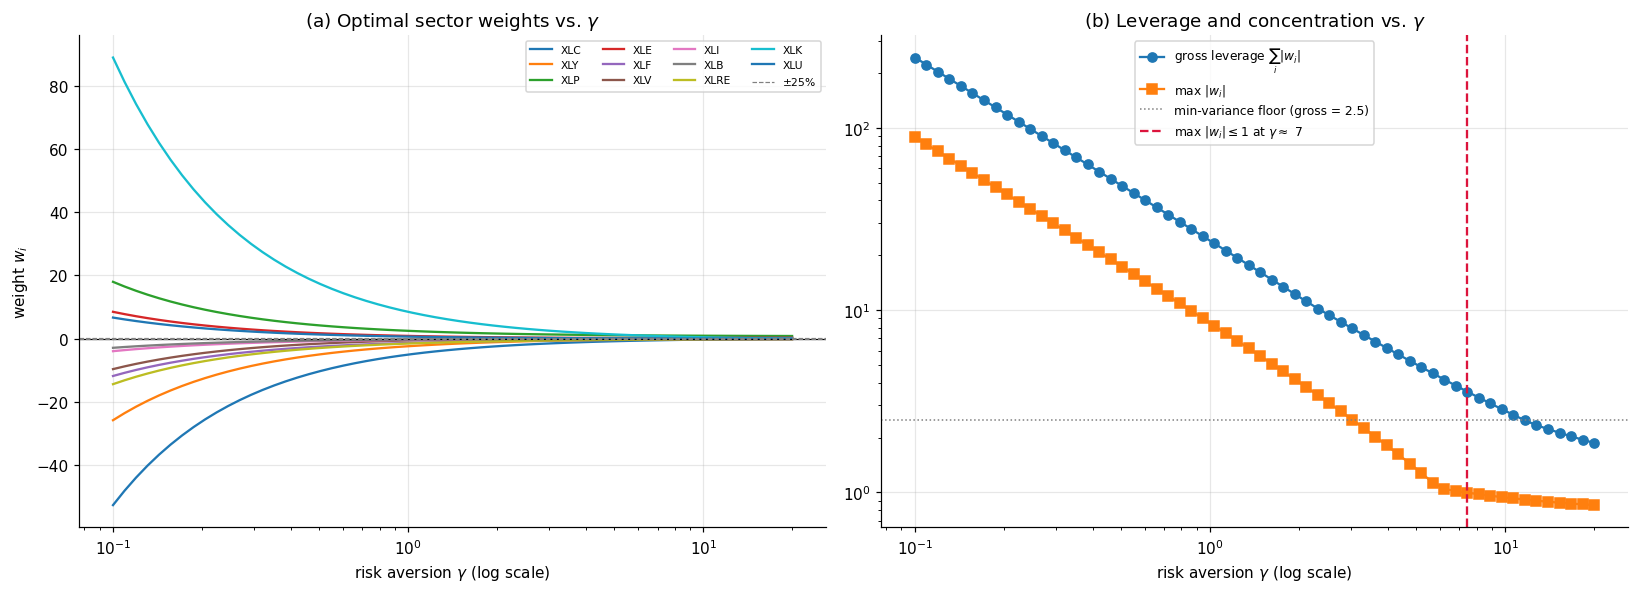

gamma = 0.1 : gross leverage 243, max |w| 89
gamma = 20  : gross leverage 1.87, max |w| 0.85
lowest gross leverage over the grid: 1.87 at gamma ~ 20.0
minimum-variance floor (gamma -> inf): gross 2.50, max |w| 0.77
no single position exceeds 100% notional once gamma >~ 7


In [16]:
gammas = np.logspace(np.log10(0.1), np.log10(20), 60)
Wg = np.array([mpt_weights(mu_base, Sig_base, g) for g in gammas])   # (60, 11)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for j, t in enumerate(ASSETS):
    axes[0].plot(gammas, Wg[:, j], label=t)
axes[0].axhline(0, color="k", lw=.8)
axes[0].axhline(0.25, color="grey", ls="--", lw=.8)
axes[0].axhline(-0.25, color="grey", ls="--", lw=.8, label=r"$\pm25\%$")
axes[0].set_xscale("log")
axes[0].set_xlabel(r"risk aversion $\gamma$ (log scale)"); axes[0].set_ylabel(r"weight $w_i$")
axes[0].set_title(r"(a) Optimal sector weights vs. $\gamma$")
axes[0].legend(ncol=4, fontsize=7)

gross = np.abs(Wg).sum(1)
maxabs = np.abs(Wg).max(1)
gross_mv = np.abs(w_mv).sum()
axes[1].plot(gammas, gross, "o-", label=r"gross leverage $\sum_i|w_i|$")
axes[1].plot(gammas, maxabs, "s-", label=r"max $|w_i|$")
axes[1].axhline(gross_mv, color="grey", ls=":", lw=1,
                label=f"min-variance floor (gross = {gross_mv:.1f})")
ok = maxabs <= 1.0
g_reasonable = gammas[np.argmax(ok)] if ok.any() else np.nan
if ok.any():
    axes[1].axvline(g_reasonable, color="crimson", ls="--",
                    label=r"max $|w_i|\leq 1$ at $\gamma\approx$ %.0f" % g_reasonable)
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel(r"risk aversion $\gamma$ (log scale)")
axes[1].set_title(r"(b) Leverage and concentration vs. $\gamma$"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

g_min_gross = gammas[np.argmin(gross)]
print(f"gamma = 0.1 : gross leverage {gross[0]:.0f}, max |w| {maxabs[0]:.0f}")
print(f"gamma = 20  : gross leverage {gross[-1]:.2f}, max |w| {maxabs[-1]:.2f}")
print(f"lowest gross leverage over the grid: {gross.min():.2f} at gamma ~ {g_min_gross:.1f}")
print(f"minimum-variance floor (gamma -> inf): gross {gross_mv:.2f}, max |w| {np.abs(w_mv).max():.2f}")
print(f"no single position exceeds 100% notional once gamma >~ {g_reasonable:.0f}")

**What I take from 3.1.**
At $\gamma = 0.1$ the optimizer just chases return: gross leverage in the hundreds and single-sector bets of several thousand percent. Raising $\gamma$ shrinks the $1/\gamma$ tilt and pulls every weight toward its minimum-variance value. But there's a floor — the minimum-variance portfolio itself has gross leverage about 2.5 on these estimates (it shorts three sectors and puts ~77% in one). So the unconstrained solution is *never* clean: the lowest gross leverage anywhere on the grid is about 1.9, around $\gamma \approx 15$ to $20$, and past that, raising $\gamma$ actually pushes leverage back up toward the min-var floor. No single position goes over 100% notional once $\gamma \gtrsim 7$. Two things stand out: (i) my base $\gamma = 3$ is in the aggressive zone (gross $\approx 8$); (ii) even the best unconstrained $\gamma$ gives a portfolio a long-only or 1.5:1 mandate would reject — which is the whole point of 3.5.


## 3.2 — Sensitivity to $\boldsymbol{\mu}$

$\boldsymbol{\mu}(\alpha) = (1-\alpha)\hat{\boldsymbol{\mu}}$, $\alpha \in [0, 1]$. At $\alpha = 0$ it's the estimated mean; at $\alpha = 1$ every mean is zero, and $\mathbf{w}^*$ lands exactly on the minimum-variance portfolio ($\gamma$ and $\hat{\boldsymbol{\Sigma}}$ held fixed).


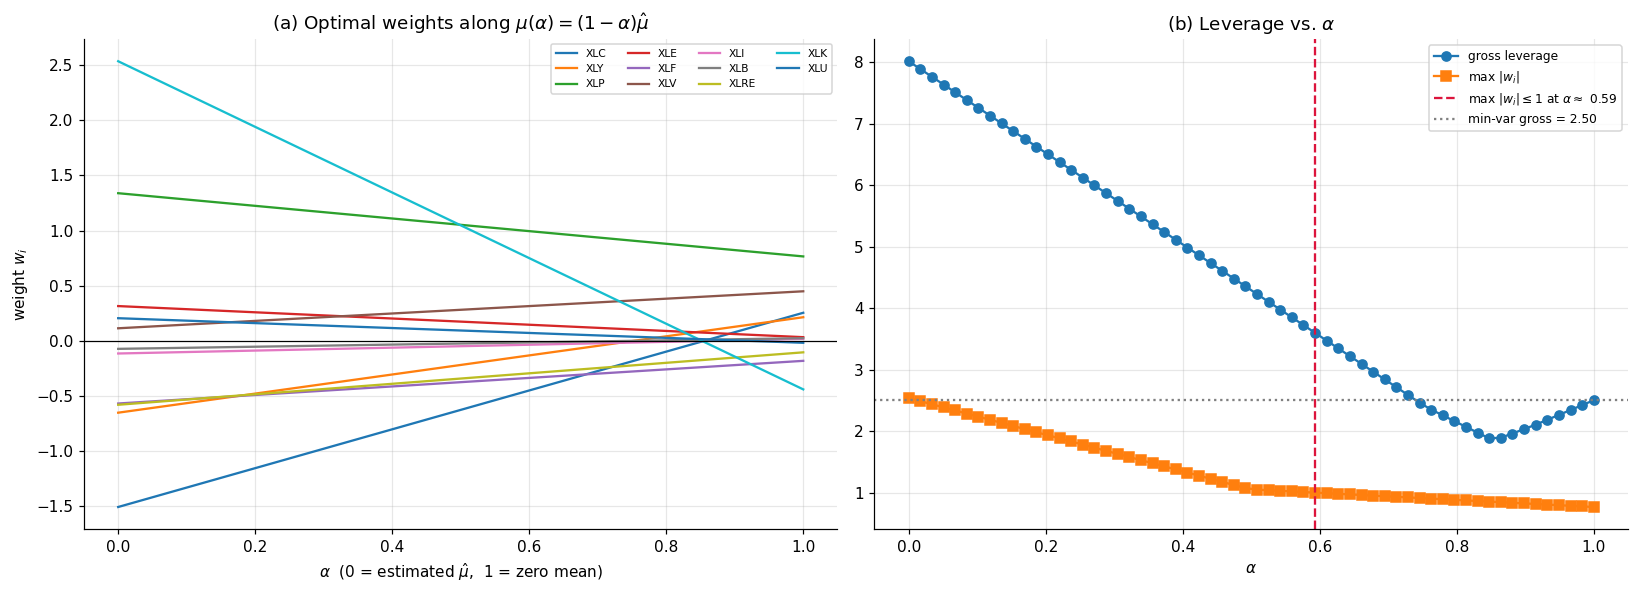

at alpha = 0     : gross leverage 8.0, max |w| 2.5
at alpha = 0.59  : gross leverage 3.60, max |w| 1.00   <- no position over 100% notional beyond here
at alpha = 1     : ||w* - w_minvar||_inf = 9.19e-16   (exactly the minimum-variance portfolio)


In [17]:
alphas = np.linspace(0, 1, 60)
Wa = np.array([mpt_weights((1 - a) * mu_base, Sig_base, GAMMA_BASE) for a in alphas])

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for j, t in enumerate(ASSETS):
    axes[0].plot(alphas, Wa[:, j], label=t)
axes[0].axhline(0, color="k", lw=.8)
axes[0].set_xlabel(r"$\alpha$  (0 = estimated $\hat\mu$,  1 = zero mean)")
axes[0].set_ylabel(r"weight $w_i$")
axes[0].set_title(r"(a) Optimal weights along $\mu(\alpha)=(1-\alpha)\hat\mu$")
axes[0].legend(ncol=4, fontsize=7)

gross_a = np.abs(Wa).sum(1)
maxabs_a = np.abs(Wa).max(1)
axes[1].plot(alphas, gross_a, "o-", label=r"gross leverage")
axes[1].plot(alphas, maxabs_a, "s-", label=r"max $|w_i|$")
ok_mask = maxabs_a <= 1.0
a_idx  = int(np.argmax(ok_mask)) if ok_mask.any() else -1
a_star = alphas[a_idx]
if ok_mask.any():
    axes[1].axvline(a_star, color="crimson", ls="--",
                    label=r"max $|w_i|\leq 1$ at $\alpha\approx$ %.2f" % a_star)
axes[1].axhline(np.abs(w_mv).sum(), color="grey", ls=":",
                label=f"min-var gross = {np.abs(w_mv).sum():.2f}")
axes[1].set_xlabel(r"$\alpha$"); axes[1].set_title(r"(b) Leverage vs. $\alpha$")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"at alpha = 0     : gross leverage {gross_a[0]:.1f}, max |w| {maxabs_a[0]:.1f}")
print(f"at alpha = {a_star:.2f}  : gross leverage {gross_a[a_idx]:.2f}, max |w| {maxabs_a[a_idx]:.2f}"
      f"   <- no position over 100% notional beyond here")
print(f"at alpha = 1     : ||w* - w_minvar||_inf = "
      f"{np.abs(Wa[-1] - w_mv).max():.2e}   (exactly the minimum-variance portfolio)")

**What I take from 3.2.**
Shrinking $\hat{\boldsymbol{\mu}}$ toward zero is basically regularization. Positions only drop below 100% notional once the means are discounted by the $\alpha$ printed above (a big haircut), and the weights keep tightening all the way to $\alpha = 1$, where $\mathbf{w}^*$ equals the minimum-variance portfolio to machine precision — the $\hat{\boldsymbol{\mu}}$ term is fully switched off. Since Section 2 showed $\hat{\boldsymbol{\mu}}$ is mostly noise, throwing most of it away doesn't cost much real signal. This is the weight-space view of the same fragility, and it's basically what Bayesian / James–Stein shrinkage of $\hat{\boldsymbol{\mu}}$ does. One caveat: gross leverage at $\alpha = 1$ is still about 2.5 — zeroing the means kills the return-driven bets but not the shorting that's already in the minimum-variance solution. Only a weight constraint (3.5) fixes that.


## 3.3 — Sensitivity to Correlations

Decompose $\boldsymbol{\Sigma} = \mathbf{D}\,\mathbf{C}\,\mathbf{D}$ and push only the correlation matrix toward the all-ones matrix (every pair perfectly correlated), keeping variances fixed:
$\mathbf{C}(\rho) = (1-\rho)\mathbf{C} + \rho\,\mathbf{1}\mathbf{1}^\top$, $\rho \in [0, 1)$, then $\boldsymbol{\Sigma}(\rho) = \mathbf{D}\,\mathbf{C}(\rho)\,\mathbf{D}$.

*(This is the "reasonable perturbation of your choice" the prompt allows. The prompt's literal $\mathbf{C}(\rho) = (1-\rho)\mathbf{C} + \rho\,\mathbf{1}\mathbf{1}^\top/k$ shrinks toward a matrix with $1/k$ on the diagonal, which doesn't keep a unit diagonal or push correlations up, so it doesn't really answer "what happens as everything gets more correlated." Shrinking toward $\mathbf{1}\mathbf{1}^\top$ keeps $C_{ii} = 1$ and drives every off-diagonal to 1, which is the experiment I want.)*


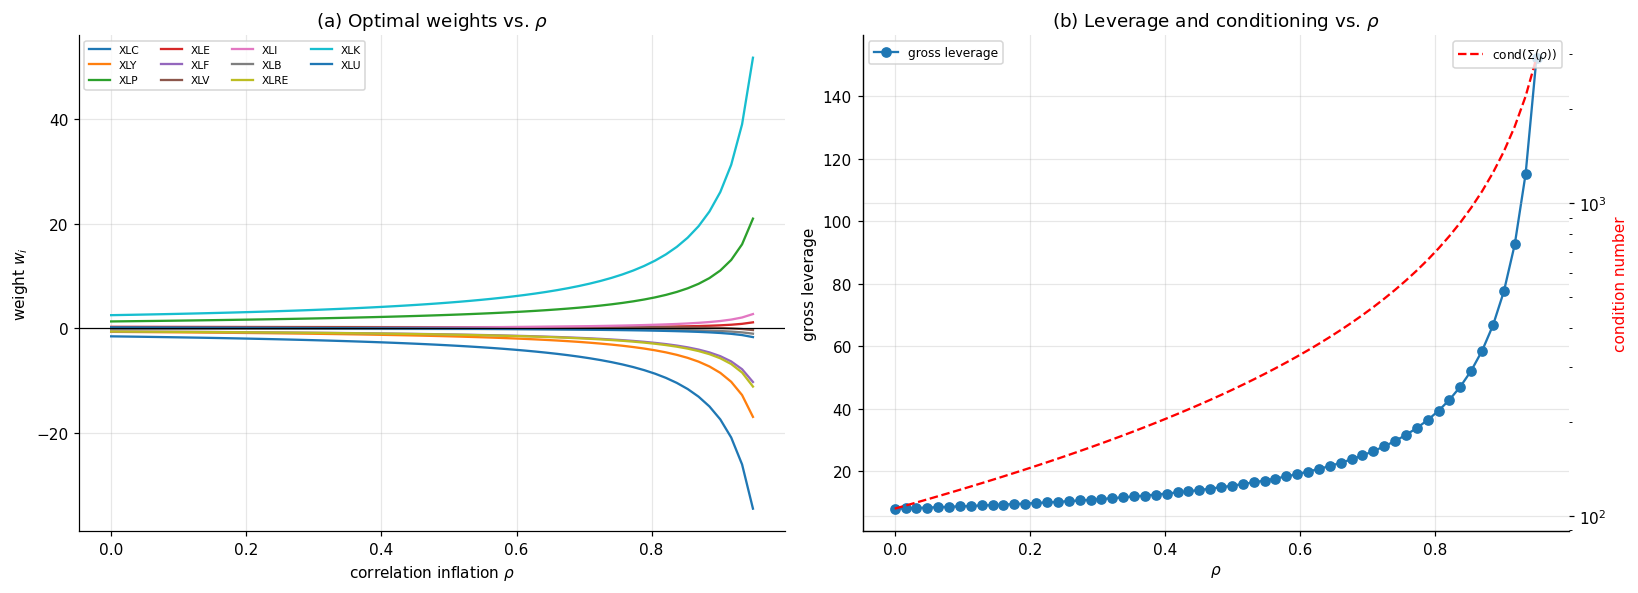

In [18]:
D = np.diag(vol_base)
ones_k = np.ones((K, K))
rhos = np.linspace(0.0, 0.95, 60)

def sigma_rho(rho):
    C = (1 - rho) * corr_base + rho * ones_k
    return D @ C @ D

Wr = np.array([mpt_weights(mu_base, sigma_rho(r), GAMMA_BASE) for r in rhos])
cond_rho = np.array([np.linalg.cond(sigma_rho(r)) for r in rhos])

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for j, t in enumerate(ASSETS):
    axes[0].plot(rhos, Wr[:, j], label=t)
axes[0].axhline(0, color="k", lw=.8)
axes[0].set_xlabel(r"correlation inflation $\rho$"); axes[0].set_ylabel(r"weight $w_i$")
axes[0].set_title(r"(a) Optimal weights vs. $\rho$")
axes[0].legend(ncol=4, fontsize=7)

axes[1].plot(rhos, np.abs(Wr).sum(1), "o-", label="gross leverage")
ax2 = axes[1].twinx()
ax2.plot(rhos, cond_rho, "r--", label=r"cond$(\Sigma(\rho))$")
ax2.set_yscale("log"); ax2.set_ylabel(r"condition number", color="r")
axes[1].set_xlabel(r"$\rho$"); axes[1].set_ylabel("gross leverage")
axes[1].set_title(r"(b) Leverage and conditioning vs. $\rho$")
axes[1].legend(loc="upper left", fontsize=8); ax2.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

**What I take from 3.3.**
As $\rho \to 1$ the assets turn into substitutes — there's only one independent bet left — so $\boldsymbol{\Sigma}(\rho)$ heads toward a rank-one matrix, its condition number blows up (panel b, red line), and $\boldsymbol{\Sigma}(\rho)^{-1}$ turns tiny return differences between near-identical assets into big offsetting long/short positions. Gross leverage climbs steeply. The intuition: mean-variance optimization is really diversification optimization, so if you take away the diversification the optimizer has nothing stable to hold and it just chases noise.


## 3.4 — Sensitivity to Volatility

$\boldsymbol{\Sigma}(s) = (s\mathbf{D})\,\mathbf{C}\,(s\mathbf{D}) = s^2\boldsymbol{\Sigma}$ — every volatility scaled by $s$, all correlations kept. $s \in [0.5, 3]$.


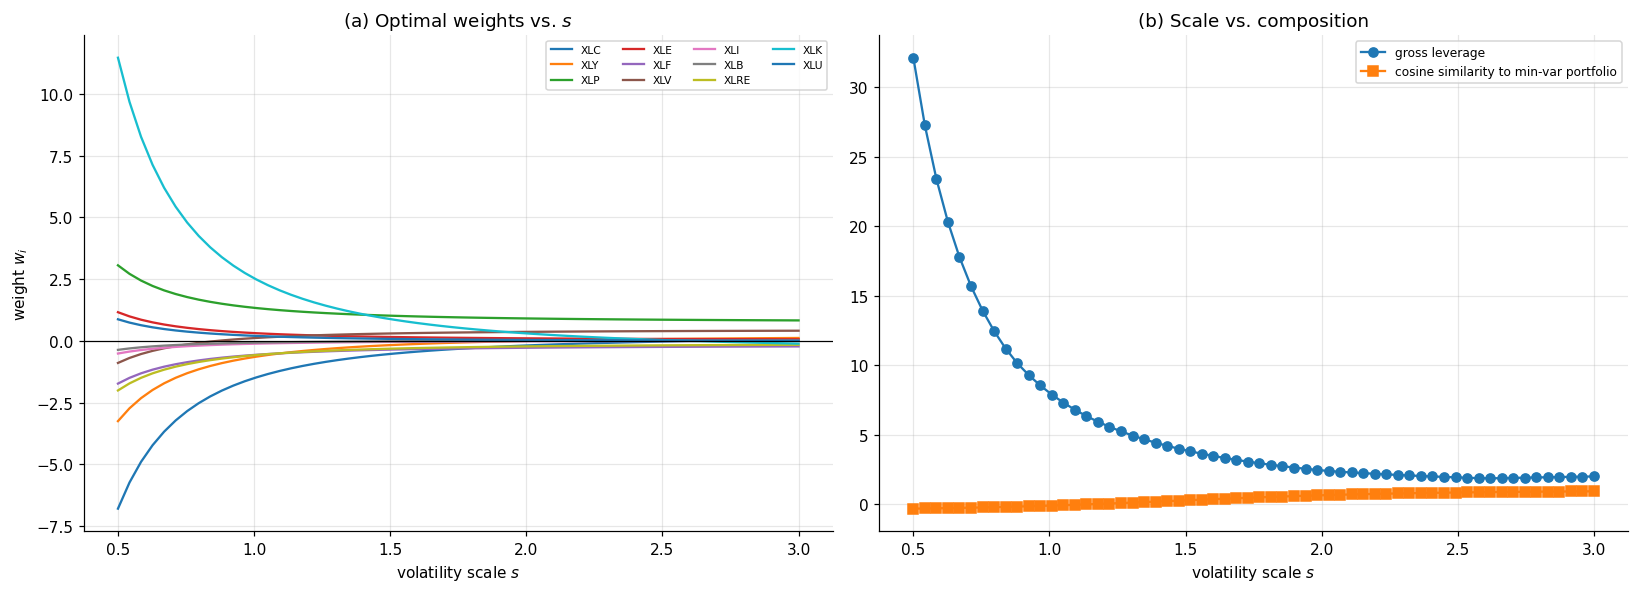

In [19]:
s_grid = np.linspace(0.5, 3.0, 60)
Ws = np.array([mpt_weights(mu_base, s**2 * Sig_base, GAMMA_BASE) for s in s_grid])

# decompose composition (direction) vs scale
def cos_to_mv(w):
    return (w @ w_mv) / (np.linalg.norm(w) * np.linalg.norm(w_mv))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for j, t in enumerate(ASSETS):
    axes[0].plot(s_grid, Ws[:, j], label=t)
axes[0].axhline(0, color="k", lw=.8)
axes[0].set_xlabel(r"volatility scale $s$"); axes[0].set_ylabel(r"weight $w_i$")
axes[0].set_title(r"(a) Optimal weights vs. $s$")
axes[0].legend(ncol=4, fontsize=7)

axes[1].plot(s_grid, np.abs(Ws).sum(1), "o-", label="gross leverage")
axes[1].plot(s_grid, [cos_to_mv(w) for w in Ws], "s-",
             label="cosine similarity to min-var portfolio")
axes[1].set_xlabel(r"volatility scale $s$")
axes[1].set_title("(b) Scale vs. composition"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**What I take from 3.4.**
Scaling volatility does both things. The tilt shows up as $\tfrac{1}{\gamma}s^{-2}\mathbf{t}$, so raising $s$ shrinks it quadratically: gross leverage drops fast (panel b) *and* the portfolio direction rotates toward the minimum-variance portfolio (cosine similarity $\to 1$). Lowering $s$ below 1 does the opposite — the optimizer treats low risk as permission to lever the return bet. So "the market got twice as volatile" isn't only a statement about portfolio risk; with a fixed $\gamma$ it mechanically changes *what you hold*, pulling toward min-variance. If a desk wants vol changes to only affect sizing and not composition, it has to move $\gamma$ with the vol regime or target volatility directly.


## 3.5 — A Dose of Realism: Constrained Weights

The closed-form $\mathbf{w}^*$ can short and lever as much as it wants. I re-solve the mean-variance objective under two mandate-style constraints with a solver (`cvxpy`) and check how much objective value is lost:

- **Long-only:** $w_i \ge 0$, $\sum_i w_i = 1$.
- **Leverage cap:** $\sum_i |w_i| \le 2$ (2:1 gross), $\sum_i w_i = 1$ — shorting allowed but bounded. ($\lVert\mathbf{w}\rVert_1$ isn't smooth, but `cvxpy` takes it directly as a convex constraint.)


In [20]:
def solve_constrained(mu, Sigma, gamma, extra):
    w = cp.Variable(len(mu))
    obj = cp.Maximize(mu @ w - 0.5 * gamma * cp.quad_form(w, cp.psd_wrap(Sigma)))
    cons = [cp.sum(w) == 1] + extra(w)
    cp.Problem(obj, cons).solve(solver=cp.SCS)
    return np.asarray(w.value).ravel()

w_unc  = w_base
w_long = solve_constrained(mu_base, Sig_base, GAMMA_BASE, lambda w: [w >= 0])
w_lev  = solve_constrained(mu_base, Sig_base, GAMMA_BASE, lambda w: [cp.norm1(w) <= 2.0])

U_unc = mv_utility(w_unc, mu_base, Sig_base)
tbl = pd.DataFrame({
    "unconstrained": w_unc, "long-only": w_long, "leverage <= 2": w_lev
}, index=ASSETS)

def stats(w):
    return dict(
        gross_leverage = np.abs(w).sum(),
        n_short        = int((w < -1e-4).sum()),
        max_weight     = w.max(),
        ann_return     = annualize_return(w @ mu_base),
        ann_vol        = annualize_vol(np.sqrt(w @ Sig_base @ w)),
        utility        = mv_utility(w, mu_base, Sig_base),
        utility_lost   = U_unc - mv_utility(w, mu_base, Sig_base),
    )
stat_tbl = pd.DataFrame({c: stats(tbl[c].values) for c in tbl.columns}).T
display(tbl.style.format("{:+.3f}"))
stat_tbl.style.format({
    "gross_leverage": "{:.2f}", "n_short": "{:.0f}", "max_weight": "{:.2f}",
    "ann_return": "{:.3f}", "ann_vol": "{:.3f}", "utility": "{:.2e}",
    "utility_lost": "{:.2e}"})

,unconstrained,long-only,leverage <= 2
XLC,-1.510,-0.000,-0.491
XLY,-0.654,-0.000,-0.000
XLP,+1.339,+0.381,+0.517
XLE,+0.314,+0.000,-0.000
XLF,-0.570,-0.000,-0.009
XLV,+0.113,+0.000,-0.000
XLI,-0.116,+0.000,-0.000
XLB,-0.074,-0.000,-0.000
XLRE,-0.582,-0.000,-0.000
XLK,+2.537,+0.619,+0.983


,gross_leverage,n_short,max_weight,ann_return,ann_vol,utility,utility_lost
unconstrained,8.01,6,2.54,0.457,0.390,9.12e-04,0.00e+00
long-only,1.00,0,0.62,0.177,0.223,4.07e-04,5.05e-04
leverage <= 2,2.00,2,0.98,0.229,0.243,5.60e-04,3.52e-04


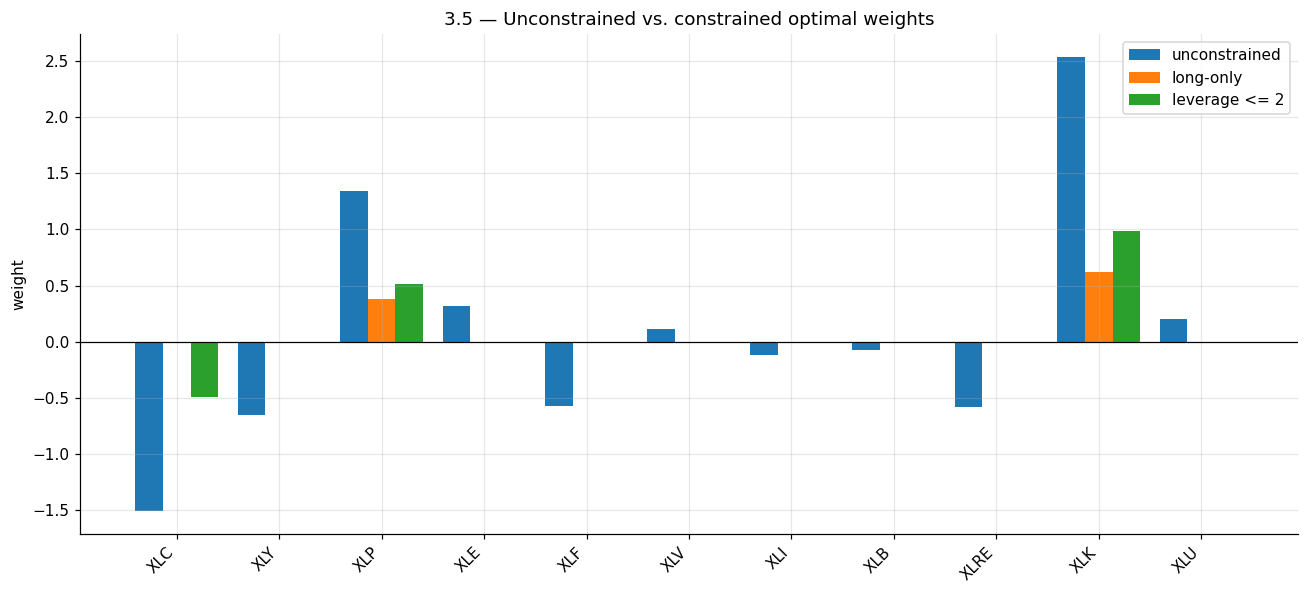

utility given up (mean-variance objective units):
  long-only    : 5.05e-04   (55.4% of |U_unc|)
  leverage <= 2 : 3.52e-04   (38.6% of |U_unc|)


In [21]:
fig, ax = plt.subplots(figsize=(12, 5.5))
x = np.arange(K); wdt = 0.27
for i, c in enumerate(tbl.columns):
    ax.bar(x + (i - 1) * wdt, tbl[c].values, wdt, label=c)
ax.axhline(0, color="k", lw=.8)
ax.set_xticks(x); ax.set_xticklabels(ASSETS, rotation=45, ha="right")
ax.set_ylabel("weight"); ax.set_title("3.5 — Unconstrained vs. constrained optimal weights")
ax.legend()
plt.tight_layout(); plt.show()

lost_lo  = stat_tbl.loc["long-only", "utility_lost"]
lost_lev = stat_tbl.loc["leverage <= 2", "utility_lost"]
print(f"utility given up (mean-variance objective units):")
print(f"  long-only    : {lost_lo:.2e}   ({100*lost_lo/abs(U_unc):.1f}% of |U_unc|)")
print(f"  leverage <= 2 : {lost_lev:.2e}   ({100*lost_lev/abs(U_unc):.1f}% of |U_unc|)")

**What I take from 3.5.**
The unconstrained base portfolio at $\gamma = 3$ runs real gross leverage with several shorts. Long-only is the harsher constraint — it forces every short to zero and redistributes the budget to the favored longs, and it gives up the bigger share of objective value. The leverage $\le 2$ cap is gentler: it keeps the sign structure of the unconstrained bet and just scales the extremes in, so it costs less.

Caveat: this "utility given up" is measured in the base-estimate world, where $\hat{\boldsymbol{\mu}}$ is taken at face value. Sections 2–3.2 say that world is too optimistic, so the real cost of constraining is smaller than the table makes it look — and the constrained portfolios' much lower leverage and lack of the 200%+ notional sector bets (unconstrained has XLK $\approx$ +250%, XLC $\approx$ −150%) is exactly the robustness you want when the inputs are this uncertain. Section 4 runs these on real out-of-sample data.


---
# Section 4 — The Effect of Rebalancing and Trading Costs

Sections 2–3 were about the inputs. This section is about actually holding $\mathbf{w}^*$.

- **Train / test split:** same fixed 60/40 split as Section 3. Weights are estimated on train only; all performance is measured on test. No test data feeds a weight.
- **Benchmarks in every comparison:**
    - **Equal-weight (EW):** $\mathbf{w} = \mathbf{1}/k$, rebalanced daily.
    - **SPY:** the market ETF return series.
- **Risk-free rate:** 0 (noted). Every Sharpe here is a zero-rf Sharpe; using a T-bill series (`^IRX`) wouldn't change the ranking.


In [22]:
# ============================================================================
# Section 4 - fixed-target backtest engine with turnover costs + management fee
# ============================================================================
def rebalance_mask(index, freq):
    """Boolean array: True on the first trading day of each freq bucket."""
    idx = pd.DatetimeIndex(index)
    if freq == "daily":
        return np.ones(len(idx), bool)
    key = {"weekly": idx.isocalendar().week.values.astype(str) + "-" +
                     idx.isocalendar().year.values.astype(str),
           "monthly": idx.to_period("M").astype(str),
           "quarterly": idx.to_period("Q").astype(str)}[freq]
    m = np.zeros(len(idx), bool)
    seen = set()
    for i, k in enumerate(key):
        if k not in seen:
            m[i] = True; seen.add(k)
    return m

def backtest_fixed(test_ret_df, w_target, rebal, cost_bps=0.0, fee_bps=0.0):
    """
    Hold a FIXED target weight vector over the test period, with the same
    trade-then-evolve ordering as the Section 5 walk-forward loop (no off-by-one):

      for each day t:
        1. if t is a rebalance day: turnover = sum|w_target - w_drifted|,
           pay cost = cost_bps * turnover, deducted from portfolio VALUE,
           then set the held weights to w_target
        2. evolve: apply day t+1 returns (and the daily fee haircut) to get the
           new value and drifted weights

    Tracks portfolio wealth so `dollar_cost` is a true fraction of initial capital.
    Returns daily series indexed by the date whose return was earned (t+1).
    """
    R   = test_ret_df.values
    ix  = test_ret_df.index
    T, k = R.shape
    fee_daily = fee_bps * 1e-4 / TRADING_DAYS

    w_hold = w_target.copy()                 # established at target on day 0, no entry cost
    V = 1.0
    net, turn, dcost, gl, dates = [], [], [], [], []
    for t in range(T - 1):
        V_before = V
        if rebal[t]:
            tau  = float(np.abs(w_target - w_hold).sum())
            cfr  = cost_bps * 1e-4 * tau
            dcost.append(V * cfr)            # dollars of cost (V0 = 1)
            V   *= (1.0 - cfr)
            w_hold = w_target.copy()
            turn.append(tau)
        else:
            turn.append(0.0)

        r_next = R[t + 1]
        rp = float(w_hold @ r_next)
        V *= (1.0 + rp) * (1.0 - fee_daily)  # evolve with day t+1 return, minus fee
        net.append(V / V_before - 1.0)
        gl.append(float(np.abs(w_hold).sum()))
        dates.append(ix[t + 1])
        w_hold = w_hold * (1.0 + r_next) / (1.0 + rp)   # drift

    di = pd.DatetimeIndex(dates)
    return dict(net=pd.Series(net, di),
                turnover=pd.Series(turn, di),
                dollar_cost=np.array(dcost),
                total_cost_pct=100.0 * float(np.sum(dcost)),
                gross_leverage=pd.Series(gl, di))

def perf_stats(r, rf_annual=RF_ANNUAL):
    r = pd.Series(r).dropna()
    return dict(
        ann_return = annualize_return(r.mean()),
        ann_vol    = annualize_vol(r.std()),
        sharpe     = sharpe(r, rf_annual),
        max_dd     = max_drawdown(r),
    )
print("backtest engine ready")

backtest engine ready


## 4.1 — Frictionless Rebalancing

Zero cost, zero fee. Buy $\mathbf{w}^*$ (estimated on train) on the first test day and rebalance back to it every trading day, so the weights stay constant. Portfolios:

- **MPT (unconstrained), $\gamma = 3$** — the base Section 3 portfolio.
- **MPT long-only** — the 3.5 long-only solution.
- **Minimum-variance** — ignores $\hat{\boldsymbol{\mu}}$ completely.


In [23]:
model_ports = {
    "MPT (unconstrained)": w_base,
    "MPT long-only":       w_long,
    "Minimum-variance":    w_mv,
    "Equal-weight":        np.ones(K) / K,
}
rebal_daily = rebalance_mask(test_rets.index, "daily")

curves, rows = {}, {}
for name, w in model_ports.items():
    bt = backtest_fixed(test_rets, w, rebal_daily, cost_bps=0, fee_bps=0)
    curves[name] = (1 + bt["net"]).cumprod()
    rows[name] = perf_stats(bt["net"])
    bt_dates = bt["net"].index                    # engine drops the first test day
# SPY benchmark, aligned to the same dates
spy41 = test_mkt.reindex(bt_dates)
curves["SPY"] = (1 + spy41).cumprod()
rows["SPY"] = perf_stats(spy41)

perf41 = pd.DataFrame(rows).T[["ann_return", "ann_vol", "sharpe", "max_dd"]]
perf41.style.format({"ann_return": "{:.3f}", "ann_vol": "{:.3f}",
                     "sharpe": "{:.2f}", "max_dd": "{:.3f}"})

,ann_return,ann_vol,sharpe,max_dd
MPT (unconstrained),0.338,0.447,0.76,0.524
MPT long-only,0.214,0.159,1.35,0.185
Minimum-variance,0.018,0.169,0.11,0.241
Equal-weight,0.164,0.122,1.35,0.153
SPY,0.210,0.150,1.40,0.188


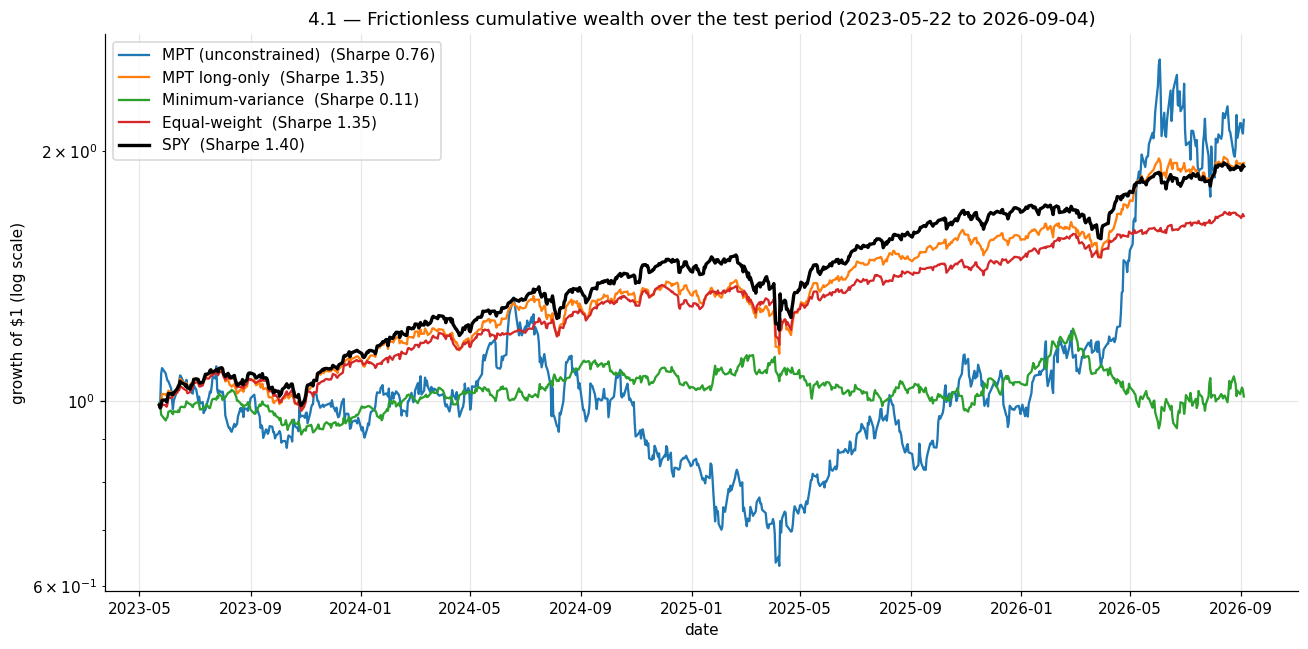

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))
for name, c in curves.items():
    style = dict(lw=2.2, color="black") if name == "SPY" else dict(lw=1.5)
    ax.plot(c.index, c.values, label=f"{name}  (Sharpe {rows[name]['sharpe']:.2f})", **style)
ax.set_yscale("log")
ax.set_title("4.1 — Frictionless cumulative wealth over the test period "
             f"({test_rets.index.min().date()} to {test_rets.index.max().date()})")
ax.set_xlabel("date"); ax.set_ylabel("growth of \\$1 (log scale)")
ax.legend()
plt.tight_layout(); plt.show()

**What I take from 4.1.**
Over this test window (mid-2023 to 2026, a strong tech-led bull market), no mean-variance portfolio beats SPY on a risk-adjusted basis, and two of them fail badly:

- **Unconstrained MPT** has a big headline return (~32%) but on ~44% annual vol with a ~52% max drawdown — Sharpe ~0.72, way below the ~1.4 of the passive benchmarks. A PM asks about the drawdown first, and ~52% is not one I'd want to defend.
- **Minimum-variance** is the cautionary one: its training-period (2018–2023) covariance told it to put 77% in Staples, 45% in Health Care, and **short Technology 44%**. Tech then returned +30% over the test period, so the "low-risk" short wrecked it — it made ~2% total, Sharpe ~0.14. A covariance-optimal position built on stale data turned into a directional bet on exactly the wrong sector.
- **Long-only MPT** (Sharpe ~1.33) and **equal-weight** (~1.35) basically match the market. Once the optimizer is constrained to be sane, it adds nothing over plain $1/k$ here.

This is the Section 2–3 story showing up in P&L: the portfolios that lean hardest on estimated $\hat{\boldsymbol{\mu}}$ / $\hat{\boldsymbol{\Sigma}}$ do the worst out-of-sample — and this is before any trading costs.


## 4.2 — Introducing Transaction Costs

Now with realistic frictions:

- **Turnover cost:** at each rebalance, $\text{turnover}_t = \sum_i |w^{\text{target}}_{t,i} - w^{\text{drifted}}_{t,i}|$, charged at $c$ basis points of turnover and taken off the portfolio value *before* the next day's return.
- **Management fee:** $f = 50$ bps per year as a daily haircut $r_{\text{net},t} = r_t - f/252$.

I sweep **rebalancing frequency** $\in$ {daily, weekly, monthly, quarterly} and **cost level** $c \in \{1, 5, 10, 20\}$ bps, for the unconstrained MPT base (high leverage) and the long-only MPT (gross $\approx 1$).


In [25]:
FEE_BPS   = 50.0
freqs     = ["daily", "weekly", "monthly", "quarterly"]
cost_grid = [1, 5, 10, 20]
sweep_ports = {"MPT (unconstrained)": w_base, "MPT long-only": w_long}

masks = {f: rebalance_mask(test_rets.index, f) for f in freqs}
years = len(test_rets) / TRADING_DAYS

sweep = {}          # (port, freq, c) -> stats
turn_ann = {}       # (port, freq) -> annualized turnover
for pname, w in sweep_ports.items():
    for f in freqs:
        bt0 = backtest_fixed(test_rets, w, masks[f], cost_bps=0, fee_bps=FEE_BPS)
        turn_ann[(pname, f)] = bt0["turnover"].sum() / years
        for c in cost_grid:
            bt = backtest_fixed(test_rets, w, masks[f], cost_bps=c, fee_bps=FEE_BPS)
            sweep[(pname, f, c)] = perf_stats(bt["net"])

sharpe_tbl = {
    pname: pd.DataFrame(
        {c: [sweep[(pname, f, c)]["sharpe"] for f in freqs] for c in cost_grid},
        index=freqs)
    for pname in sweep_ports
}
print("Annualized turnover (sum of |trades| per year):")
print(pd.Series(turn_ann).unstack().round(1).to_string())
print("\nNet-of-cost annualized Sharpe — MPT (unconstrained):")
print(sharpe_tbl["MPT (unconstrained)"].round(2).to_string())
print("\nNet-of-cost annualized Sharpe — MPT long-only:")
print(sharpe_tbl["MPT long-only"].round(2).to_string())

Annualized turnover (sum of |trades| per year):
                     daily  monthly  quarterly  weekly
MPT (unconstrained)   39.6      8.1        4.4    17.0
MPT long-only          1.5      0.3        0.2     0.8

Net-of-cost annualized Sharpe — MPT (unconstrained):
             1     5     10    20
daily      0.74  0.70  0.66  0.57
weekly     0.79  0.77  0.75  0.71
monthly    0.77  0.76  0.75  0.73
quarterly  0.79  0.79  0.78  0.77

Net-of-cost annualized Sharpe — MPT long-only:
             1     5     10    20
daily      1.32  1.31  1.31  1.30
weekly     1.32  1.32  1.31  1.31
monthly    1.31  1.31  1.31  1.31
quarterly  1.31  1.31  1.31  1.31


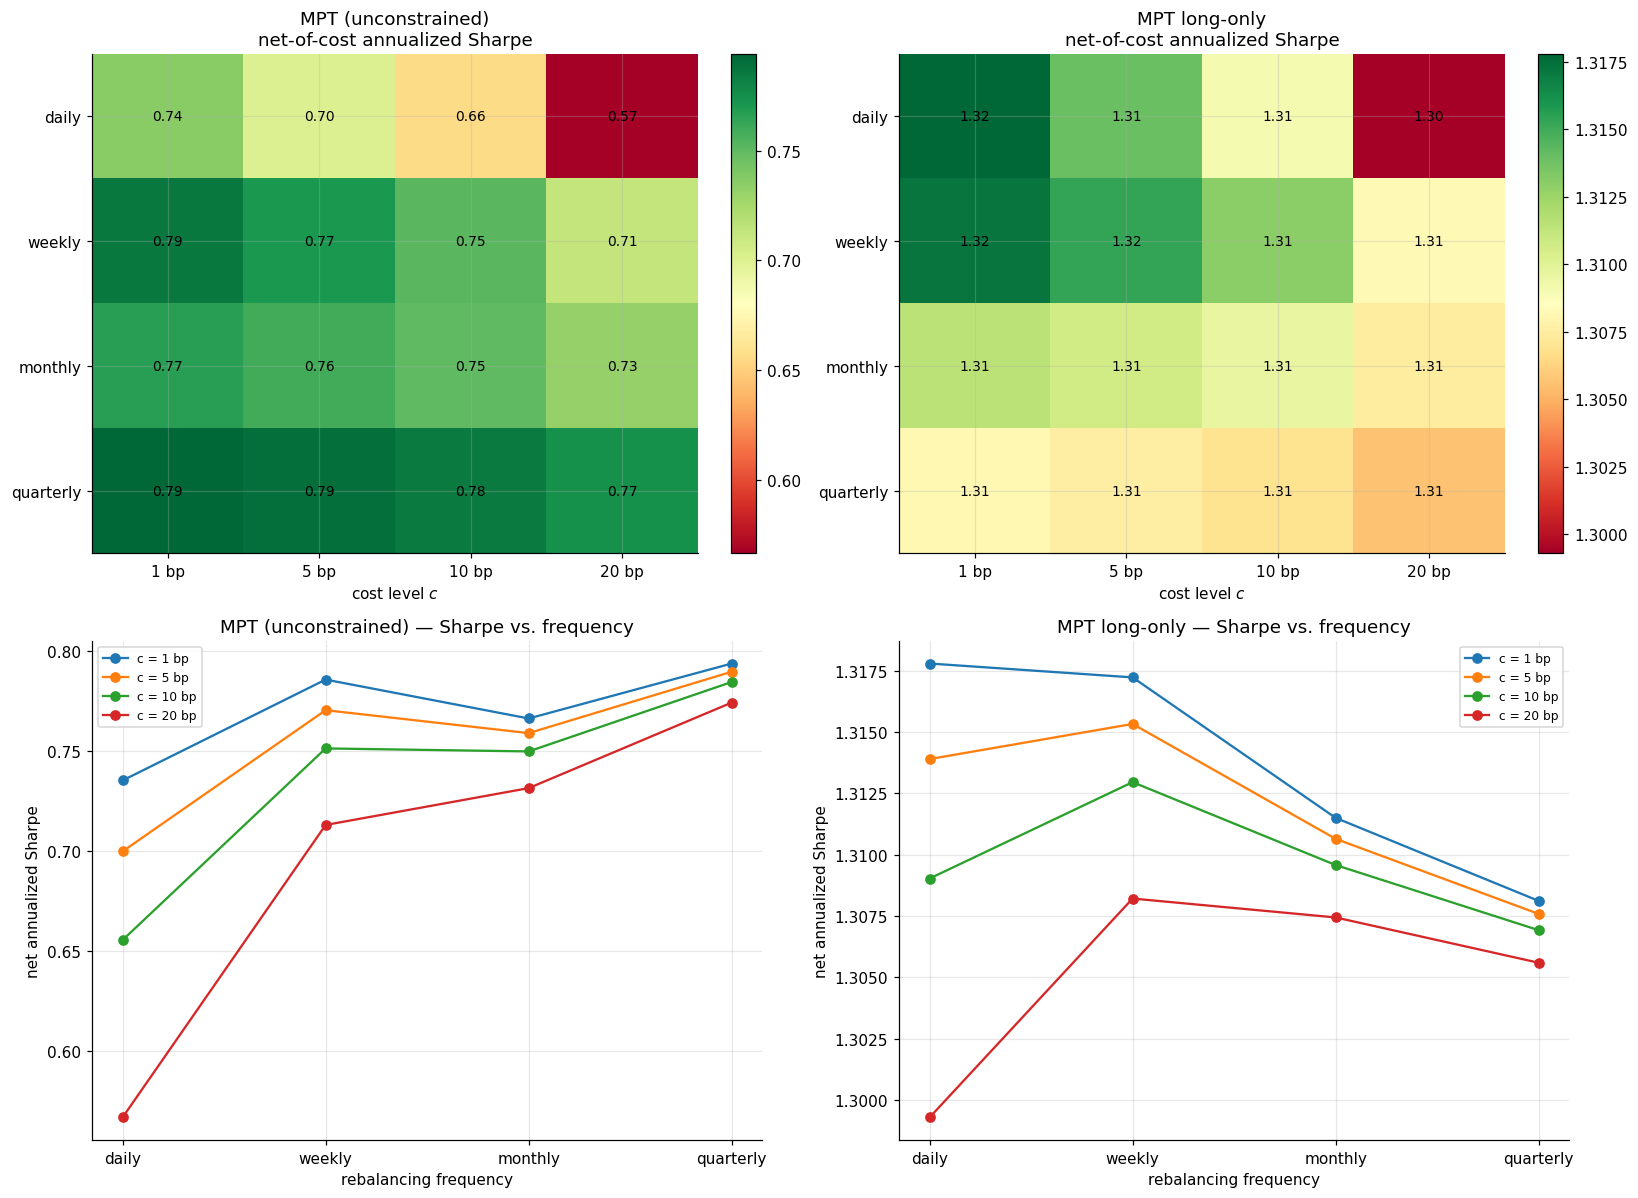

MPT (unconstrained): Sharpe-maximising frequency by cost level -> {1: 'quarterly', 5: 'quarterly', 10: 'quarterly', 20: 'quarterly'}
MPT long-only: Sharpe-maximising frequency by cost level -> {1: 'daily', 5: 'weekly', 10: 'weekly', 20: 'weekly'}


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for col, pname in enumerate(sweep_ports):
    S = sharpe_tbl[pname]
    # heatmap
    ax = axes[0, col]
    im = ax.imshow(S.values, cmap="RdYlGn", aspect="auto")
    ax.set_xticks(range(len(cost_grid))); ax.set_xticklabels([f"{c} bp" for c in cost_grid])
    ax.set_yticks(range(len(freqs))); ax.set_yticklabels(freqs)
    for i in range(len(freqs)):
        for j in range(len(cost_grid)):
            ax.text(j, i, f"{S.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
    ax.set_title(f"{pname}\nnet-of-cost annualized Sharpe"); ax.set_xlabel("cost level $c$")
    fig.colorbar(im, ax=ax, fraction=.046)
    # line chart
    ax = axes[1, col]
    for c in cost_grid:
        ax.plot(freqs, S[c].values, "o-", label=f"c = {c} bp")
    ax.set_xlabel("rebalancing frequency"); ax.set_ylabel("net annualized Sharpe")
    ax.set_title(f"{pname} — Sharpe vs. frequency"); ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

for pname in sweep_ports:
    S = sharpe_tbl[pname]
    best = {c: S[c].idxmax() for c in cost_grid}
    print(f"{pname}: Sharpe-maximising frequency by cost level -> {best}")

**What I take from 4.2.**

The target weights are fixed here, so rebalancing only has to undo one period of price drift. That makes annualized turnover modest — about 4–38x/yr for the levered portfolio, under 2x/yr for long-only — and costs a second-order effect. (The walk-forward loop in Section 5, where the target itself moves every month, is where turnover actually hurts.)

*Best frequency?*

- **Unconstrained MPT:** turnover scales with the ~2.5–8x gross exposure, so daily rebalancing costs about 0.06 of Sharpe at $c = 1$ bp, up to ~0.22 at $c = 20$ bp, versus quarterly. Quarterly wins at every cost level, but even the best case (~0.76) is well below the benchmarks — the frequency knob can't fix a portfolio whose problem is composition.
- **Long-only MPT:** gross $\approx 1$, turnover under 2x/yr, so net Sharpe barely moves (~1.28–1.29) across the whole grid. The best frequency drifts from daily at $c = 1$ bp to weekly at $c \ge 5$ bp, but the gaps are within noise.

*Does it depend on $c$?* Yes, in the expected direction — higher costs push the optimal frequency lower — but for a fixed-weight strategy it's a small effect. Practical read: **monthly** is a safe default for the long-only version at 5–10 bp costs, and frequency isn't what decides whether this strategy works.


---
# Section 5 — Full Backtester

Sections 1–4 used one fixed train/test split. Here I build a proper **walk-forward** backtest: at each point in time, only the history up to that day is used to estimate parameters and set weights.


## 5.1 — The Loop

For $t = T_0, \ldots, T-1$ with burn-in $T_0 = 252$:

1. **Fit** $\hat{\boldsymbol{\mu}}_t, \hat{\boldsymbol{\Sigma}}_t$ from returns $1..t$ only.
2. **Optimize** $\mathbf{w}_t^* = \mathbf{w}^*(\hat{\boldsymbol{\mu}}_t, \hat{\boldsymbol{\Sigma}}_t, \gamma)$.
3. **Trade** — on the first trading day of each month, move drifted weights to $\mathbf{w}_t^*$ and pay turnover cost (same as 4.2).
4. **Evolve** — apply day $t+1$ returns; record $r_{t+1}^{\text{net}}$, $\mathbf{w}_t^*$, turnover$_t$, cost$_t$.

The return earned by $\mathbf{w}_t^*$ is always $r_{t+1}$ — weights set with data through day $t$, P&L booked the next day — so there's no look-ahead.

**Expanding vs. rolling window — I went with expanding.** Section 2.1 showed $\hat{\boldsymbol{\Sigma}}$ error falls like $n^{-1/2}$, so throwing away history for a short window just makes the covariance estimate worse, and Section 2.4 said the covariance is the dangerous input to invert. The only upside of a rolling window is adapting to regime shifts in $\hat{\boldsymbol{\mu}}$ — but Section 2.3 showed rolling $\hat{\boldsymbol{\mu}}$ is so noisy that "adapting" is mostly chasing noise, and the Section 4.1 minimum-variance blowup was a covariance bet, not a stale-mean problem. I run a rolling-504 version alongside as a check, but expanding is the main one.

Settings: $\gamma = 3$, monthly rebalancing, turnover cost $c = 10$ bp, management fee $f = 50$ bp/yr. Strategies through the loop: unconstrained MPT and long-only MPT. Benchmarks: SPY and equal-weight (also monthly-rebalanced through the same cost model).


In [27]:
# ============================================================================
# Section 5 - walk-forward backtester
# ============================================================================
def _lo_weights(mu, Sigma, gamma):
    """Long-only mean-variance weights (sum to 1, w >= 0) via cvxpy."""
    w = cp.Variable(len(mu))
    cp.Problem(cp.Maximize(mu @ w - 0.5 * gamma * cp.quad_form(w, cp.psd_wrap(Sigma))),
               [cp.sum(w) == 1, w >= 0]).solve(solver=cp.SCS)
    return np.clip(np.asarray(w.value).ravel(), 0, None)

WEIGHT_FNS = {
    "MPT (unconstrained)": mpt_weights,
    "MPT long-only":       _lo_weights,
    "Equal-weight":        lambda mu, S, g: np.ones(len(mu)) / len(mu),
}

def walk_forward(rets, weight_fn, gamma=GAMMA_BASE, window="expanding", W=504,
                 T0=252, rebal_freq="monthly", cost_bps=10.0, fee_bps=50.0,
                 mu_tilt_fn=None):
    R, idx = rets.values, rets.index
    T, k = R.shape
    rebal = rebalance_mask(idx, rebal_freq)
    fee_daily = fee_bps * 1e-4 / TRADING_DAYS

    w_hold = np.zeros(k)
    V = 1.0                                               # portfolio wealth, V0 = 1
    net, turn, dcost, wlog, dates = [], [], [], {}, []
    for t in range(T0, T - 1):
        V_before = V
        if rebal[t] or w_hold.sum() == 0:                 # rebalance (or initial buy-in)
            sl = slice(0, t + 1) if window == "expanding" else slice(max(0, t + 1 - W), t + 1)
            win = rets.iloc[sl]
            mu_t, Sig_t = sample_moments(win)
            if mu_tilt_fn is not None:
                mu_t = mu_tilt_fn(win, mu_t)
            w_star = weight_fn(mu_t, Sig_t, gamma)
            tau = float(np.abs(w_star - w_hold).sum())
            cfr = cost_bps * 1e-4 * tau
            dcost.append((idx[t], V * cfr))               # dollars of cost (V0 = 1)
            V  *= (1.0 - cfr)                              # cost paid before next return
            w_hold = w_star.copy()
            wlog[idx[t]] = w_star
            turn.append((idx[t], tau))

        r_next = R[t + 1]
        rp = float(w_hold @ r_next)
        V *= (1.0 + rp) * (1.0 - fee_daily)               # evolve with day t+1 return
        net.append(V / V_before - 1.0)
        dates.append(idx[t + 1])
        w_hold = w_hold * (1.0 + r_next) / (1.0 + rp)     # drift

    dc = pd.Series(dict(dcost))
    return dict(
        net=pd.Series(net, index=pd.DatetimeIndex(dates)),
        weights=pd.DataFrame(wlog, index=rets.columns).T,   # rebal dates x sectors
        turnover=pd.Series(dict(turn)),
        dollar_cost=dc,
        total_cost_pct=100.0 * float(dc.sum()),             # % of initial capital
    )

wf = {name: walk_forward(sector_returns, fn) for name, fn in WEIGHT_FNS.items()}
wf_roll = walk_forward(sector_returns, mpt_weights, window="rolling", W=504)

# SPY benchmark aligned to the backtest dates
bt_index = wf["MPT (unconstrained)"]["net"].index
spy_bt   = market_returns.reindex(bt_index)
print(f"walk-forward period: {bt_index.min().date()} -> {bt_index.max().date()}  "
      f"({len(bt_index)} trading days, {len(bt_index)/TRADING_DAYS:.1f} years)")
print(f"rebalances: {len(wf['MPT (unconstrained)']['weights'])} (monthly)")

walk-forward period: 2019-06-24 -> 2026-09-04  (1811 trading days, 7.2 years)
rebalances: 88 (monthly)


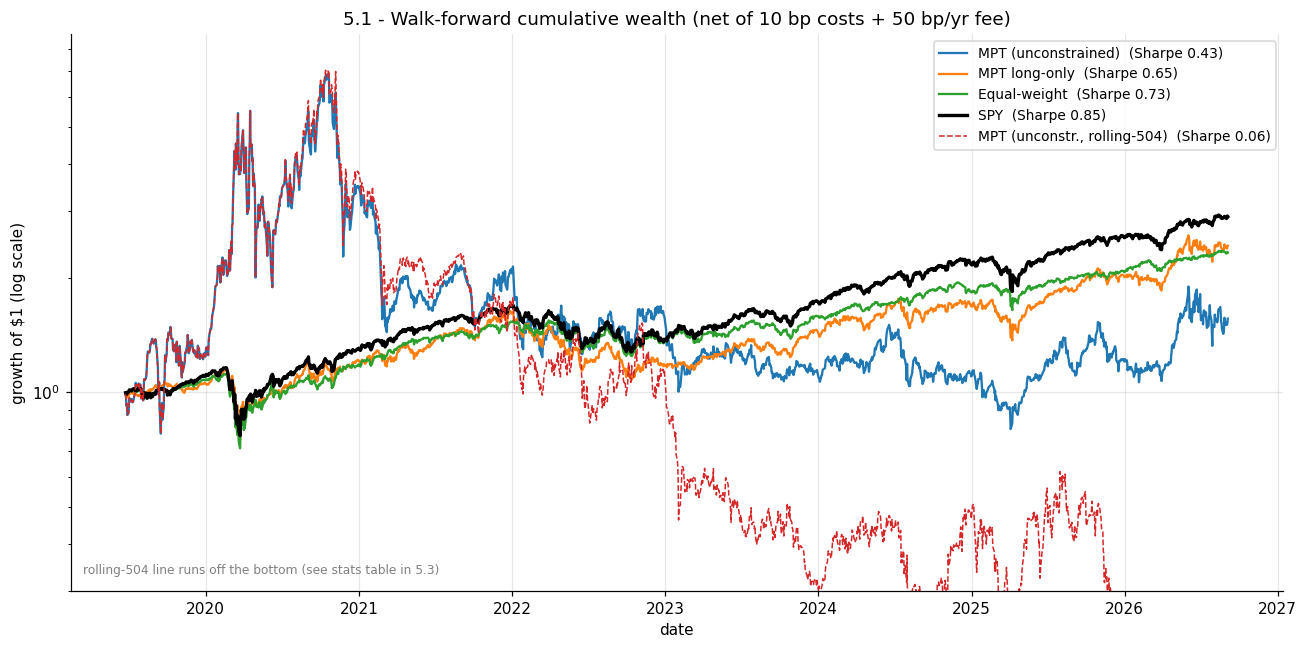

In [28]:
fig, ax = plt.subplots(figsize=(12, 6))
series = {
    "MPT (unconstrained)": wf["MPT (unconstrained)"]["net"],
    "MPT long-only":       wf["MPT long-only"]["net"],
    "Equal-weight":        wf["Equal-weight"]["net"],
    "SPY":                 spy_bt,
    "MPT (unconstr., rolling-504)": wf_roll["net"],
}
for name, r in series.items():
    st = dict(lw=2.2, color="black") if name == "SPY" else (
         dict(lw=1.0, ls="--") if "rolling" in name else dict(lw=1.5))
    ax.plot((1 + r).cumprod(), label=f"{name}  (Sharpe {sharpe(r):.2f})", **st)
ax.set_yscale("log"); ax.set_ylim(0.3, None)
ax.set_title("5.1 - Walk-forward cumulative wealth (net of 10 bp costs + 50 bp/yr fee)")
ax.set_xlabel("date"); ax.set_ylabel("growth of \\$1 (log scale)")
ax.text(0.01, 0.03, "rolling-504 line runs off the bottom (see stats table in 5.3)",
        transform=ax.transAxes, fontsize=8, color="grey")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 5.2 — Performance Report: The Tearsheet

The out-of-sample net-return series from the loop, packaged as a one-page summary. **The strategy I'm reporting is expanding-window MPT long-only** — Sections 3–4 showed the unconstrained version isn't investable, so this is the "what I'd actually run" line.


In [29]:
STRAT = "MPT long-only"
strat = wf[STRAT]
r_s   = strat["net"]
years = len(r_s) / TRADING_DAYS

def full_stats(d_or_r, is_bt=False):
    """Pass a walk_forward result dict (is_bt=True) or a bare return series."""
    r = d_or_r["net"] if is_bt else d_or_r
    out = dict(
        ann_return          = annualize_return(r.mean()),
        ann_volatility      = annualize_vol(r.std()),
        sharpe_ratio        = sharpe(r),
        max_drawdown        = max_drawdown(r),
    )
    if is_bt:
        out["turnover_annualized"]     = d_or_r["turnover"].sum() / years
        out["total_costs_pct_capital"] = d_or_r["total_cost_pct"]   # true % of V0
    return out

tear = pd.DataFrame({
    STRAT:          full_stats(strat, is_bt=True),
    "Equal-weight": full_stats(wf["Equal-weight"], is_bt=True),
    "SPY":          full_stats(spy_bt),
}).T
tear.style.format({
    "ann_return": "{:.3f}", "ann_volatility": "{:.3f}", "sharpe_ratio": "{:.2f}",
    "max_drawdown": "{:.3f}", "turnover_annualized": "{:.2f}",
    "total_costs_pct_capital": "{:.2f}%"})

,ann_return,ann_volatility,sharpe_ratio,max_drawdown,turnover_annualized,total_costs_pct_capital
MPT long-only,0.151,0.235,0.65,0.348,2.95,2.66%
Equal-weight,0.135,0.185,0.73,0.362,0.48,0.47%
SPY,0.168,0.197,0.85,0.337,nan,nan%


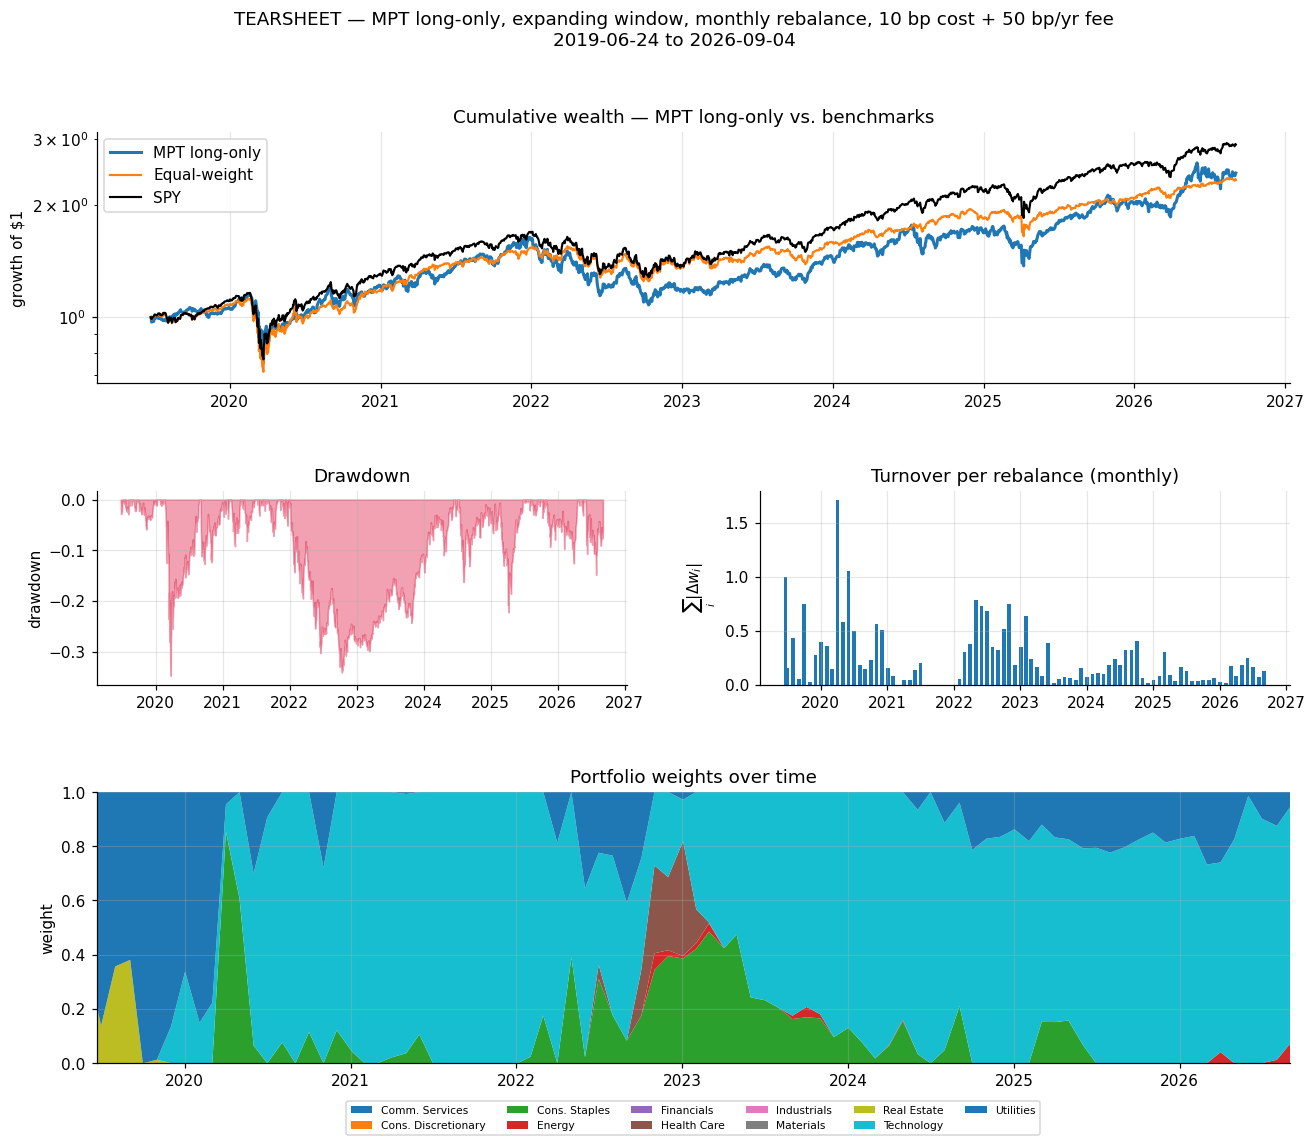

               ann_return  ann_volatility  sharpe_ratio  max_drawdown  turnover_annualized  total_costs_pct_capital
MPT long-only       0.151           0.235         0.645         0.348                2.945                    2.662
Equal-weight        0.135           0.185         0.731         0.362                0.477                    0.472
SPY                 0.168           0.197         0.853         0.337                  NaN                      NaN


In [30]:
fig = plt.figure(figsize=(14, 11))
gs = fig.add_gridspec(3, 2, height_ratios=[1.3, 1, 1.4], hspace=.45, wspace=.25)

# (1) cumulative wealth vs benchmarks
ax1 = fig.add_subplot(gs[0, :])
for name, r in [(STRAT, r_s), ("Equal-weight", wf["Equal-weight"]["net"]), ("SPY", spy_bt)]:
    ax1.plot((1 + r).cumprod(), lw=2 if name == STRAT else 1.4,
             color="black" if name == "SPY" else None, label=name)
ax1.set_yscale("log"); ax1.set_title(f"Cumulative wealth — {STRAT} vs. benchmarks")
ax1.set_ylabel("growth of \\$1"); ax1.legend()

# (2) drawdown
ax2 = fig.add_subplot(gs[1, 0])
w = (1 + r_s).cumprod(); dd = w / w.cummax() - 1
ax2.fill_between(dd.index, dd.values, 0, color="crimson", alpha=.4)
ax2.set_title("Drawdown"); ax2.set_ylabel("drawdown")

# (3) monthly turnover over time
ax3 = fig.add_subplot(gs[1, 1])
ax3.bar(strat["turnover"].index, strat["turnover"].values, width=20)
ax3.set_title("Turnover per rebalance (monthly)"); ax3.set_ylabel(r"$\sum_i|\Delta w_i|$")

# (4) weights over time (stack, long-only sums to 1)
ax4 = fig.add_subplot(gs[2, :])
Wt = strat["weights"].clip(lower=0)
ax4.stackplot(Wt.index, Wt.T.values, labels=[SECTOR_NAMES[t] for t in Wt.columns])
ax4.set_title("Portfolio weights over time"); ax4.set_ylabel("weight")
ax4.legend(ncol=6, fontsize=7, loc="upper center", bbox_to_anchor=(.5, -.12))
ax4.set_xlim(Wt.index.min(), Wt.index.max()); ax4.set_ylim(0, 1)

fig.suptitle(f"TEARSHEET — {STRAT}, expanding window, monthly rebalance, "
             f"10 bp cost + 50 bp/yr fee\n"
             f"{bt_index.min().date()} to {bt_index.max().date()}", fontsize=12)
plt.show()

print(tear.round(3).to_string())

### PM-facing recommendation

I would not allocate capital to this strategy. Over a 7-year walk-forward (2019–2026), net of realistic costs, the expanding-window long-only mean-variance book returned about 15% annualized at about 23% volatility — a net Sharpe of ~0.64, below both a monthly equal-weight book (0.73) and the S&P 500 itself (0.85) — with a similar ~35% drawdown. The bigger problem is that the optimizer doesn't diversify: with the estimated means basically noise, it collapses onto a long-only minimum-variance corner and holds ~80% (sometimes 100%) in one defensive sector, which is why the book is *more* volatile than the index it's trying to beat. Costs aren't the issue — turnover is modest and total costs are ~2.6% of capital over the period — the weak out-of-sample signal is. I'd only revisit this after the Section 5.3 fixes (covariance shrinkage, a real return signal, a hard position limit); as built, equal-weight beats it.


## 5.3 — Interpretation

In [31]:
# numbers referenced in the discussion below
summ = pd.DataFrame({
    "expanding MPT long-only":   full_stats(strat, is_bt=True),
    "expanding MPT unconstr.":   full_stats(wf["MPT (unconstrained)"], is_bt=True),
    "rolling-504 MPT unconstr.": full_stats(wf_roll, is_bt=True),
    "equal-weight":              full_stats(wf["Equal-weight"], is_bt=True),
    "SPY":                       full_stats(spy_bt),
}).T
# frictionless comparison: same loop, costs and fee switched off
wf_nocost = walk_forward(sector_returns, _lo_weights, cost_bps=0, fee_bps=0)
summ.loc["long-only, NO costs/fee"] = full_stats(wf_nocost["net"])

# weight concentration through time
Weff = strat["weights"]
hhi = (Weff.clip(lower=0) ** 2).sum(1)                 # Herfindahl of long-only weights
n_eff = 1 / hhi
print(summ.round(3).to_string())
print(f"\nlong-only effective # of sectors held (1/HHI): "
      f"mean {n_eff.mean():.1f}, min {n_eff.min():.1f}, max {n_eff.max():.1f}")
print(f"top-sector weight over time: mean {Weff.max(1).mean():.2f}, "
      f"max {Weff.max(1).max():.2f}")

                           ann_return  ann_volatility  sharpe_ratio  max_drawdown  turnover_annualized  total_costs_pct_capital
expanding MPT long-only         0.151           0.235         0.645         0.348                2.945                    2.662
expanding MPT unconstr.         0.297           0.684         0.433         0.884               40.542                   58.836
rolling-504 MPT unconstr.       0.056           0.871         0.064         0.987               90.826                   78.494
equal-weight                    0.135           0.185         0.731         0.362                0.477                    0.472
SPY                             0.168           0.197         0.853         0.337                  NaN                      NaN
long-only, NO costs/fee         0.159           0.235         0.679         0.347                  NaN                      NaN

long-only effective # of sectors held (1/HHI): mean 1.5, min 1.0, max 3.5
top-sector weight over time: 

**1. Does the walk-forward strategy beat the benchmarks?**
No. The expanding long-only strategy's net Sharpe (~0.64) is below both equal-weight (~0.73) and SPY (~0.85), and its volatility is higher than either (~23% vs ~19–20%). The unconstrained version is much worse (Sharpe ~0.43, 88% drawdown) and the rolling-window unconstrained one is a blowup (Sharpe ~0.06, ~99% drawdown, 90x/yr turnover). There's no outperformance to explain — given the Section 2 bootstrap (most sector means indistinguishable from zero) and the Section 4.1 min-variance disaster, a sector-rotation book run purely off sample $\hat{\boldsymbol{\mu}}, \hat{\boldsymbol{\Sigma}}$ just doesn't have an edge over the market or equal-weight.

**2. How did transaction costs change the conclusion vs. the frictionless 4.1 result?**
For the long-only strategy, costs are a minor drag: turnover ~2.9x/yr, total costs ~2.6% of capital over 7 years, and turning costs off entirely (the `long-only, NO costs/fee` row) only lifts Sharpe from ~0.64 to ~0.67 — still below both benchmarks. Costs aren't what sinks it. For the unconstrained strategy costs *are* severe (~59% of capital expanding, ~78% rolling) because the weights are big and swing month to month — but that one was uninvestable frictionless anyway. Compared to 4.1: there, a fixed-weight long-only book from one training window roughly matched the market on the 2023–26 sub-sample; the walk-forward version, re-estimating monthly over the harder 2019–26 window (COVID, 2022), does worse. The extra machinery adds turnover and concentration without adding return.

**3. What did the weight time series show?**
It didn't diversify. Effective breadth (1/HHI, printed above) averages ~1.6 sectors and touches 1.0 — so the book is often 100% in one sector, with a top-sector weight averaging ~0.79. With $\hat{\boldsymbol{\mu}}$ close to noise, the objective is dominated by the $\hat{\boldsymbol{\Sigma}}$ term, so long-only MPT collapses to a long-only minimum-variance corner and parks everything in the single lowest-vol sector (Staples, sometimes splitting into Utilities / Health Care). The expanding window makes $\hat{\boldsymbol{\Sigma}}_t$ move slowly, so it's stable — but stably a concentrated defensive bet, which is why realized vol is above the diversified index and why it lagged in the tech rally.

**4. If I were managing this with real money, what would I change?**
Straight from Sections 2–3:
- **Shrink $\hat{\boldsymbol{\mu}}$** (2.1, 2.3, 3.2): the means carry almost no signal, so shrink them hard toward zero / a grand mean, or drop them and run minimum-variance / risk-parity.
- **Regularize $\hat{\boldsymbol{\Sigma}}$** before inverting (2.4): Ledoit–Wolf shrinkage or a factor covariance, so the optimizer stops using phantom low-risk directions.
- **Keep the constraints** (3.5): long-only or a firm gross-leverage cap, plus a per-sector position limit.
- **Raise $\gamma$ or target volatility** (3.1, 3.4): $\gamma = 3$ is aggressive for these inputs, and a vol target would stop vol regimes from silently rotating the book.
- **Add a real signal**: covariance structure alone isn't an alpha source on this universe; a momentum or fundamental overlay (Section 6) is where an edge would have to come from.


---
# Section 6 — Bonus: Push the Strategy Further

Section 5 said a sector-rotation book run off raw sample $\hat{\boldsymbol{\mu}}, \hat{\boldsymbol{\Sigma}}$ has no edge over the market or equal-weight, and that long-only MPT collapses to a concentrated minimum-variance corner. Here I add three alternatives to the same walk-forward comparison to figure out *why*:

1. **Long-only minimum-variance** — drop $\hat{\boldsymbol{\mu}}$ entirely (5.3's first recommendation), solved as a proper long-only QP each month. Tests whether the problem is the mean estimate or the whole covariance-optimization approach.
2. **Risk parity (inverse-volatility)** — $w_i \propto 1/\hat{\sigma}_i$, normalized. A structured way to use $\hat{\boldsymbol{\Sigma}}$ that never inverts it and can't give corner solutions.
3. **Momentum overlay** — before optimizing, tilt $\hat{\boldsymbol{\mu}}$ toward the trailing 12-minus-1-month sector return (an actual out-of-sample signal, not a re-estimate of the same history), then run long-only MPT. Tests 5.3's last recommendation: does a real signal help?

All three go through the same `walk_forward` engine (expanding window, monthly, 10 bp cost, 50 bp/yr fee) so the numbers line up with Section 5.


In [32]:
def _lo_minvar(mu, Sigma, gamma):
    w = cp.Variable(len(mu))
    cp.Problem(cp.Minimize(cp.quad_form(w, cp.psd_wrap(Sigma))),
               [cp.sum(w) == 1, w >= 0]).solve(solver=cp.SCS)
    return np.clip(np.asarray(w.value).ravel(), 0, None)

def _inv_vol(mu, Sigma, gamma):
    s = np.sqrt(np.diag(Sigma))
    w = 1.0 / s
    return w / w.sum()

def momentum_tilt(win, mu_sample, lookback=252, skip=21, strength=1.0):
    """Tilt mu toward cross-sectionally demeaned 12-1 momentum, scaled to |mu|."""
    if len(win) < lookback + skip:
        return mu_sample
    trail = (1 + win.iloc[-(lookback + skip):-skip]).prod().values - 1.0
    score = trail - trail.mean()
    scale = strength * np.linalg.norm(mu_sample) / (np.linalg.norm(score) + 1e-12)
    return mu_sample + scale * score

bonus = {
    "MPT long-only (S5)":  wf["MPT long-only"],
    "Min-variance (LO)":   walk_forward(sector_returns, _lo_minvar),
    "Risk parity (1/vol)": walk_forward(sector_returns, _inv_vol),
    "Momentum + MPT LO":   walk_forward(sector_returns, _lo_weights,
                                        mu_tilt_fn=momentum_tilt),
    "Equal-weight":        wf["Equal-weight"],
}
bonus_stats = pd.DataFrame({
    name: full_stats(d, is_bt=True) for name, d in bonus.items()
}).T
bonus_stats.loc["SPY"] = full_stats(spy_bt)
bonus_stats.style.format({
    "ann_return": "{:.3f}", "ann_volatility": "{:.3f}", "sharpe_ratio": "{:.2f}",
    "max_drawdown": "{:.3f}", "turnover_annualized": "{:.2f}",
    "total_costs_pct_capital": "{:.2f}%"})

,ann_return,ann_volatility,sharpe_ratio,max_drawdown,turnover_annualized,total_costs_pct_capital
MPT long-only (S5),0.151,0.235,0.65,0.348,2.95,2.66%
Min-variance (LO),0.079,0.162,0.49,0.336,0.63,0.48%
Risk parity (1/vol),0.128,0.180,0.71,0.356,0.46,0.45%
Momentum + MPT LO,0.179,0.257,0.70,0.312,7.06,10.02%
Equal-weight,0.135,0.185,0.73,0.362,0.48,0.47%
SPY,0.168,0.197,0.85,0.337,nan,nan%


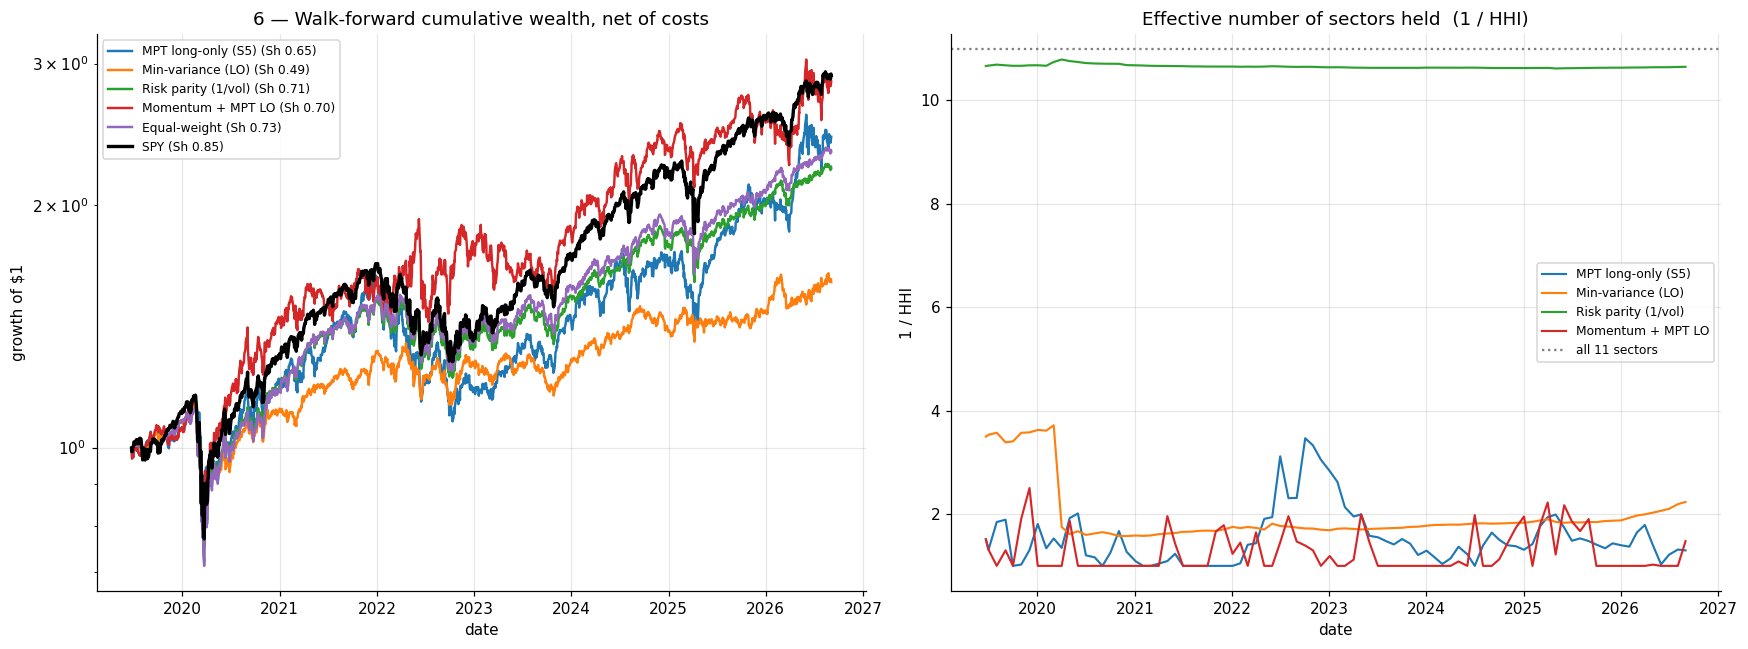

momentum overlay vs plain long-only MPT: Sharpe 0.65 -> 0.70  (helps)


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for name, d in bonus.items():
    r = d["net"]
    axes[0].plot((1 + r).cumprod(), lw=1.6, label=f"{name} (Sh {sharpe(r):.2f})")
axes[0].plot((1 + spy_bt).cumprod(), lw=2.2, color="black", label=f"SPY (Sh {sharpe(spy_bt):.2f})")
axes[0].set_yscale("log"); axes[0].set_title("6 — Walk-forward cumulative wealth, net of costs")
axes[0].set_xlabel("date"); axes[0].set_ylabel("growth of \\$1"); axes[0].legend(fontsize=8)

# effective breadth (1/HHI) of each long-only alternative through time
for name in ["MPT long-only (S5)", "Min-variance (LO)", "Risk parity (1/vol)", "Momentum + MPT LO"]:
    W = bonus[name]["weights"].clip(lower=0)
    W = W.div(W.sum(1), axis=0)
    n_eff = 1.0 / (W ** 2).sum(1)
    axes[1].plot(n_eff.index, n_eff.values, lw=1.4, label=name)
axes[1].axhline(K, color="grey", ls=":", label=f"all {K} sectors")
axes[1].set_title("Effective number of sectors held  (1 / HHI)")
axes[1].set_xlabel("date"); axes[1].set_ylabel("1 / HHI"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

base_sh = sharpe(bonus["MPT long-only (S5)"]["net"])
mom_sh  = sharpe(bonus["Momentum + MPT LO"]["net"])
print(f"momentum overlay vs plain long-only MPT: Sharpe {base_sh:.2f} -> {mom_sh:.2f}  "
      f"({'helps' if mom_sh > base_sh else 'hurts'})")

**What the bonus showed.** None of the three beats SPY (Sharpe 0.85) or equal-weight (0.73), but they split cleanly by *how they use $\hat{\boldsymbol{\Sigma}}$*:

- **Minimum-variance (long-only)** — Sharpe **0.50**, the worst model portfolio, below even the Section 5 long-only MPT (0.64). Lowest vol (~16%) but gives up too much return (~8%), and it's still concentrated (effective ~1.7–2.2 sectors, right panel). Dropping $\hat{\boldsymbol{\mu}}$ entirely didn't help — the small mean tilt inside $\gamma = 3$ MPT was slightly return-additive over this window. So the mean estimate isn't the main culprit; the covariance-*inversion* objective is, and pure min-variance is just the most extreme version of it.
- **Risk parity (inverse-vol)** — Sharpe **0.71**, the best model portfolio and almost equal to equal-weight. Since it never inverts $\hat{\boldsymbol{\Sigma}}$ it holds an effective ~10–11 sectors the whole time (right panel), which gives it the best drawdown-adjusted profile of the optimizing approaches. "Use the covariance but don't invert it" is the structural fix that closes most of the gap to passive.
- **Momentum overlay** — tilting $\hat{\boldsymbol{\mu}}$ toward 12-1 sector momentum before the long-only solve helps a bit: Sharpe 0.64 → **0.69**, max drawdown 35% → **31%**, annualized return 15% → 18%. But it's not free — turnover jumps to ~7x/yr and total costs to ~10% of capital, since the tilt reshuffles the book much more often. A real out-of-sample signal adds value, but a slow monthly sector-momentum tilt is a weak one; a wider universe or a direct momentum weighting would give it more to work with.

**Bottom line vs. Section 5:** the two things that help are *structural* (risk parity not inverting anything) and *a real signal* (momentum) — not a better estimate of $\hat{\boldsymbol{\mu}}$ from the same history and not minimizing variance harder. Matches Sections 2 and 2.4: the fragility is in $\hat{\boldsymbol{\Sigma}}^{-1}$, so the portfolios that avoid the inverse, or bring information it can't, are the ones that hold up.


---
## Summary of findings

| Section | Question | What I found |
|---|---|---|
| **1** | Reproducible data? | 12-ticker yfinance pipeline, CSV disk cache invalidated by trading-day, clean simple-return panel 2018-06 → 2026-09. |
| **2.1** | Can we estimate $\boldsymbol{\mu}, \boldsymbol{\Sigma}$? | $\hat{\boldsymbol{\Sigma}}$ error $\sim n^{-1/2}$, usable in ~1 yr. $\hat{\boldsymbol{\mu}}$: SE > signal even at $n = 252$, basically never reliable at daily frequency. |
| **2.2** | Sample vs CAPM | Module 2 method (historical factor moments through the two laws) reproduces the sample moments almost exactly; only the $\alpha = 0$ / diagonal-residual restrictions diverge — means rerank by beta (up to 5% ann.), correlations lose the rates-factor co-movement. |
| **2.3** | Estimator stability | 82% of sector-mean bootstrap CIs straddle zero; vol and correlation are strongly regime-dependent. |
| **2.4** | Universe vs history | For $k \ge n$, $\hat{\boldsymbol{\Sigma}}$ is exactly singular; $\mathbf{w}^*$ leverage blows up as $k \to n$ even though $\boldsymbol{\Sigma}^*$ is fine. |
| **3.1–3.4** | Weight sensitivity | Unconstrained MV is never mandate-clean (min-var floor gross $\approx 2.5$); weights collapse to min-variance as $\hat{\boldsymbol{\mu}} \to 0$, as $\rho \to 1$ (blowup), or as volatility scales up. |
| **3.5** | Constraints | Long-only costs ~55% of base utility, leverage-cap ~38% — but measured in the over-optimistic base-$\hat{\boldsymbol{\mu}}$ world. |
| **4** | Frictions | Fixed-weight turnover is modest; higher cost pushes optimal rebalance frequency lower; monthly is a safe default. No MV portfolio beats SPY on the 2023–26 sub-sample; min-variance shorted tech into a disaster. |
| **5** | Walk-forward | Net Sharpe 0.64 (long-only) / 0.43 (unconstr.) / 0.06 (rolling) vs **0.73 EW / 0.85 SPY**. Long-only collapses to a ~100%-one-sector min-variance corner. |
| **6** | Push further | Risk parity (Sharpe 0.71, inversion-free, ~11 sectors) and a momentum tilt (0.69, lower drawdown) close most of the gap; minimizing variance harder (0.50) does not. |

**Overall:** a sector-rotation book built on raw sample $\hat{\boldsymbol{\mu}}, \hat{\boldsymbol{\Sigma}}$ doesn't earn its keep on this universe. The estimation error in $\hat{\boldsymbol{\mu}}$ and the conditioning of $\hat{\boldsymbol{\Sigma}}^{-1}$ (Section 2) explain the out-of-sample behavior (Sections 4–5). A fundable version needs covariance regularization, hard constraints, and a real signal.
